# **Problem Statement**

## Business Context

A sales forecast is a prediction of future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action.

Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. An accurate sales forecast process has many benefits which include improved decision-making about the future and reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establish benchmarks that can be used to assess trends in the future.

## Objective

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalize these insights at scale, the company has partnered with a data science firm—not just to build a predictive model based on historical sales data, but to develop and deploy a robust forecasting solution that can be integrated into SuperKart’s decision-making systems and used across its network of stores.

## Data Description

The data contains the different attributes of the various products and stores.The detailed data dictionary is given below.

- **Product_Id** - unique identifier of each product, each identifier having two letters at the beginning followed by a number.
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product like low sugar, regular and no sugar
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type** - broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store depending on sq. feet like high, medium and low
- **Store_Location_City_Type** - type of city in which the store is located like Tier 1, Tier 2 and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than its Tier 2 and Tier 3 counterparts.
- **Store_Type** - type of store depending on the products that are being sold there like Departmental Store, Supermarket Type 1, Supermarket Type 2 and Food Mart
- **Product_Store_Sales_Total** - total revenue generated by the sale of that particular product in that particular store


# **Installing and Importing the necessary libraries**

In [118]:
#Installing the libraries with the specified versions
# !pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 joblib==1.4.2 xgboost==2.1.4 requests==2.32.4 
# !pip install huggingface_hub==0.34.0 -q

**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [119]:
import warnings
warnings.filterwarnings("ignore")
import datetime
import os

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# For splitting the dataset
from sklearn.model_selection import train_test_split

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)

from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

# Libraries to get different metric scores
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

# To create the pipeline
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline, Pipeline

# To tune different models and standardize
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder

# To serialize the model
import joblib

# os related functionalities
import os

# API request
import requests

from github import Github


# **Loading the dataset**

In [120]:
# loading data into a pandas dataframe
load_dataset = pd.read_csv("SuperKart.csv")

In [121]:
# Creating copy of the dataset
data = load_dataset.copy()

# **Data Overview**

Examining the structure of our dataset. This helps verify that the data loaded correctly and gives us an initial sense of the features available.

In [122]:
data.head(5)

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


In [123]:
data.tail(5)

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
8758,NC7546,14.80,No Sugar,0.016,Health and Hygiene,140.53,OUT004,2009,Medium,Tier 2,Supermarket Type2,3806.53
8759,NC584,14.06,No Sugar,0.142,Household,144.51,OUT004,2009,Medium,Tier 2,Supermarket Type2,5020.74
8760,NC2471,13.48,No Sugar,0.017,Health and Hygiene,88.58,OUT001,1987,High,Tier 2,Supermarket Type1,2443.42
8761,NC7187,13.89,No Sugar,0.193,Household,168.44,OUT001,1987,High,Tier 2,Supermarket Type1,4171.82
8762,FD306,14.73,Low Sugar,0.177,Snack Foods,224.93,OUT002,1998,Small,Tier 3,Food Mart,2186.08


**Observations**: 
- Initial head and tail dataset inspection reveals no missing values or apparent structural anomalies.
- The Product_Id feature exhibits a prefix pattern requiring evaluation for feature extraction or transformation prior to model training.

### Checking Shape of the dataset

In [124]:
data.shape

(8763, 12)

#### Observations: 
- The dataset contains 8763 rows and 12 columns.

### Checking the Dataset Schema and Null Values

In [125]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   object 
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   object 
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   object 
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   object 
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   object 
 9   Store_Location_City_Type   8763 non-null   object 
 10  Store_Type                 8763 non-null   object 
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 821.7+ KB


#### Observations:
- Dataset is complete with zero null values across all features.
- Numerical features: `Product_Weight`, `Product_Allocated_Area`, `Product_MRP`, `Store_Establishment_Year`, and `Product_Store_Sales_Total`.
- Remaining object type features require conversion to category dtype to optimize memory allocation and downstream computational efficiency.

In [126]:
# Count total missing values per column
data.isnull().sum()

Product_Id                   0
Product_Weight               0
Product_Sugar_Content        0
Product_Allocated_Area       0
Product_Type                 0
Product_MRP                  0
Store_Id                     0
Store_Establishment_Year     0
Store_Size                   0
Store_Location_City_Type     0
Store_Type                   0
Product_Store_Sales_Total    0
dtype: int64

#### Observation:
- There are no Null or Missing Values in the given dataset.

### Checking for Duplicate data

In [127]:
# Check for total number of duplicate rows in the dataset
duplicate_count = data.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


#### Observations:
- There is no duplicated data in the dataset.

### Check unique values per column

In [128]:
# Count the number of unique values in each column
data.nunique()

Product_Id                   8763
Product_Weight               1113
Product_Sugar_Content           4
Product_Allocated_Area        228
Product_Type                   16
Product_MRP                  6100
Store_Id                        4
Store_Establishment_Year        4
Store_Size                      3
Store_Location_City_Type        3
Store_Type                      4
Product_Store_Sales_Total    8668
dtype: int64

#### Observation:
- `Product_Id` (8763) and `Product_Store_Sales_Total` (8668) have almost all unique values — first is just an ID to drop, second is the target to predict.
- `Product_Sugar_Content`, `Store_Size`, `Store_Location_City_Type`, `Store_Type`, and `Store_Establishment_Year` have very few unique values — good for category encoding.
- `Product_Weight`, `Product_MRP`, and `Product_Allocated_Area` have many values as they are Numerical features.

## Data Cleaning

In [129]:
# The Product_Id column has 8763 unique values, which is the same as the total number of entries in the dataset.
# This indicates that Product_Id does not provide any discriminating information for predicting sales totals.
# However, the first two letters in the Product_Id seem to encode information that maybe useful in training model.
# Find unique codes and their frequency
print("Unique 2-letter prefixes:")
display(data['Product_Id'].str[:2].value_counts(dropna=False))

Unique 2-letter prefixes:


Product_Id
FD    6539
NC    1519
DR     705
Name: count, dtype: int64

#### Observation :
- `Product_Id` prefixes fall into only 3 groups: FD, NC, and DR.
- FD is the largest group with 6539 rows, far ahead of the others.
- NC (1519) and DR (705) are much smaller, with DR being the rarest.

In [130]:
# Convert object data type column into category type
for column in data.columns:
    if data[column].dtype == "object":
      data[column] = pd.Categorical(data[column])

In [131]:
# Identify categorical columns based on object dtype
categorical_cols = data.select_dtypes(include='category').columns

# Display value counts for each categorical column
for col in categorical_cols:
    print(f"\nValue counts for '{col}':\n")
    print(data[col].value_counts())


Value counts for 'Product_Id':

Product_Id
DR1005    1
FD7181    1
FD7173    1
FD7176    1
FD7178    1
         ..
FD3637    1
FD3636    1
FD3634    1
FD3633    1
NC993     1
Name: count, Length: 8763, dtype: int64

Value counts for 'Product_Sugar_Content':

Product_Sugar_Content
Low Sugar    4885
Regular      2251
No Sugar     1519
reg           108
Name: count, dtype: int64

Value counts for 'Product_Type':

Product_Type
Fruits and Vegetables    1249
Snack Foods              1149
Frozen Foods              811
Dairy                     796
Household                 740
Baking Goods              716
Canned                    677
Health and Hygiene        628
Meat                      618
Soft Drinks               519
Breads                    200
Hard Drinks               186
Others                    151
Starchy Foods             141
Breakfast                 106
Seafood                    76
Name: count, dtype: int64

Value counts for 'Store_Id':

Store_Id
OUT004    4676
OUT001    1

### Observation - 
- Some of the columns values appear to be slightly imbalanced. Need to review distribution further during the EDA process.
- In Product_Sugar_Content, the categories 'reg' and 'Regular' likely represent the same sugar content level and may need to be consolidated during preprocessing.
- The Store_Id and Store_Type columns show similar distributions and top frequencies, suggesting a strong correlation or direct mapping between particular store IDs and their types.

### Statistical Summary of the Dataset

In [132]:
# Display descriptive statistics for all columns
# .T transposes the table to make it easier to read with column names as row headers.
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Product_Weight,8763.0,12.653792,2.217320,4.000,11.150,12.660,14.180,22.000
Product_Allocated_Area,8763.0,0.068786,0.048204,0.004,0.031,0.056,0.096,0.298
Product_MRP,8763.0,147.032539,30.694110,31.000,126.160,146.740,167.585,266.000
Store_Establishment_Year,8763.0,2002.032751,8.388381,1987.000,1998.000,2009.000,2009.000,2009.000
Product_Store_Sales_Total,8763.0,3464.003640,1065.630494,33.000,2761.715,3452.340,4145.165,8000.000


#### Observation - 
- **Product_Weight:** The distribution of product weights is largely symmetrical, with a mean of approximately 12.65 units and a median of 12.66 units, ranging from 4 to 22 units.
- **Product_Allocated_Area:** The allocated display area for products exhibits a right-skewed distribution, as indicated by its mean (0.068) being greater than its median (0.056), suggesting a concentration of smaller areas with a tail extending to larger values.
- **Product_MRP:** Product prices display a distribution that is nearly symmetrical, with a mean of 147.03 and a median of 146.74, spanning a range from 31 to 266.
- **Store_Establishment_Year:** The establishment years of stores show a left-skewed distribution, with a mean of 2002 and a median of 2009, implying a higher frequency of more recently established stores within the dataset.
- **Product_Store_Sales_Total:** The total product store sales are right-skewed, characterized by a mean (3464.00) slightly higher than the median (3452.34), and a notable spread between the third quartile (4145.16) and the maximum value (8000), suggesting the presence of high-revenue sales events.

In [133]:
data.describe(include='category').T

,count,unique,top,freq
Product_Id,8763,8763,DR1005,1
Product_Sugar_Content,8763,4,Low Sugar,4885
Product_Type,8763,16,Fruits and Vegetables,1249
Store_Id,8763,4,OUT004,4676
Store_Size,8763,3,Medium,6025
Store_Location_City_Type,8763,3,Tier 2,6262
Store_Type,8763,4,Supermarket Type2,4676


#### Observation -
- **Product_Id:** Each product has a unique identifier, with 8763 unique values across 8763 records, indicating no repeated product IDs.
- **Product_Sugar_Content:** The sugar content category contains 4 unique groups, with "Low Sugar" being the most common category, appearing in 4885 records.
- **Product_Type:** The dataset contains 16 different product types, with "Fruits and Vegetables" being the most frequently occurring category at 1249 records.
- **Store_Id:** There are 4 unique stores in the dataset, with "OUT004" contributing the highest number of records (4676).
- **Store_Size:** Store size is represented by 3 categories, with "Medium" being the dominant size category, accounting for 6025 records.
- **Store_Location_City_Type:** The dataset includes 3 city tiers, with "Tier 2" stores forming the majority of observations at 6262 records.
- **Store_Type:** There are 4 store types in the dataset, with "Supermarket Type2" being the most common, appearing in 4676 records.

In [134]:
# Inspect the Store_Id and Store_Type features as the frequency matches
display(data["Store_Id"].value_counts().sort_values(ascending=False))
display(data["Store_Type"].value_counts().sort_values(ascending=False))

Store_Id
OUT004    4676
OUT001    1586
OUT003    1349
OUT002    1152
Name: count, dtype: int64

Store_Type
Supermarket Type2     4676
Supermarket Type1     1586
Departmental Store    1349
Food Mart             1152
Name: count, dtype: int64

#### Observation
- Product Type: The Product_Type column stands out with 16 distinct categories, significantly more than other categorical features like Product_Sugar_Content, Store_Id, Store_Size, Store_Location_City_Type, and Store_Type, which each have only 3 or 4 unique values.
- Store_Id and Store_Type: The Store_Id 'OUT004' and Store_Type 'Supermarket Type2' are the most frequent entries in their respective columns, both appearing 4676 times. This suggests that 'OUT004' is primarily a 'Supermarket Type2'.

# **Exploratory Data Analysis (EDA)**

- Defined the target variable and selected relevant numerical and categorical predictors for the regression model.
- Excluding Product_Id and Store_Id for now, since they are unique identifiers that do not contribute predictive value. I will revist it later part

### Defining Categorical, Numerical and Target features

In [135]:
# Define the target variable for prediction
target = 'Product_Store_Sales_Total'

# Manually selected numerical features (excluding identifier columns)
numeric_features = [
    'Product_Weight',
    'Product_Allocated_Area',
    'Product_MRP',
    'Store_Establishment_Year'
]

# Manually selected categorical features based on domain knowledge
categorical_features = [
    'Product_Sugar_Content',
    'Product_Type',
    'Store_Size',
    'Store_Location_City_Type',
    'Store_Type'
]

# List of all numeric columns in the dataset (for quick analysis)
cols_list = data.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Print the selected and detected columns for verification
print("All numeric columns detected:", cols_list)
print("-" * 100)
print("Target variable:", target)
print("-" * 100)
print("Manually selected numeric features:", numeric_features)
print("-" * 100)
print("Categorical features:", categorical_features)

All numeric columns detected: ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Establishment_Year', 'Product_Store_Sales_Total']
----------------------------------------------------------------------------------------------------
Target variable: Product_Store_Sales_Total
----------------------------------------------------------------------------------------------------
Manually selected numeric features: ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Establishment_Year']
----------------------------------------------------------------------------------------------------
Categorical features: ['Product_Sugar_Content', 'Product_Type', 'Store_Size', 'Store_Location_City_Type', 'Store_Type']


## Univariate Analysis

### Analyzing Categorical Features

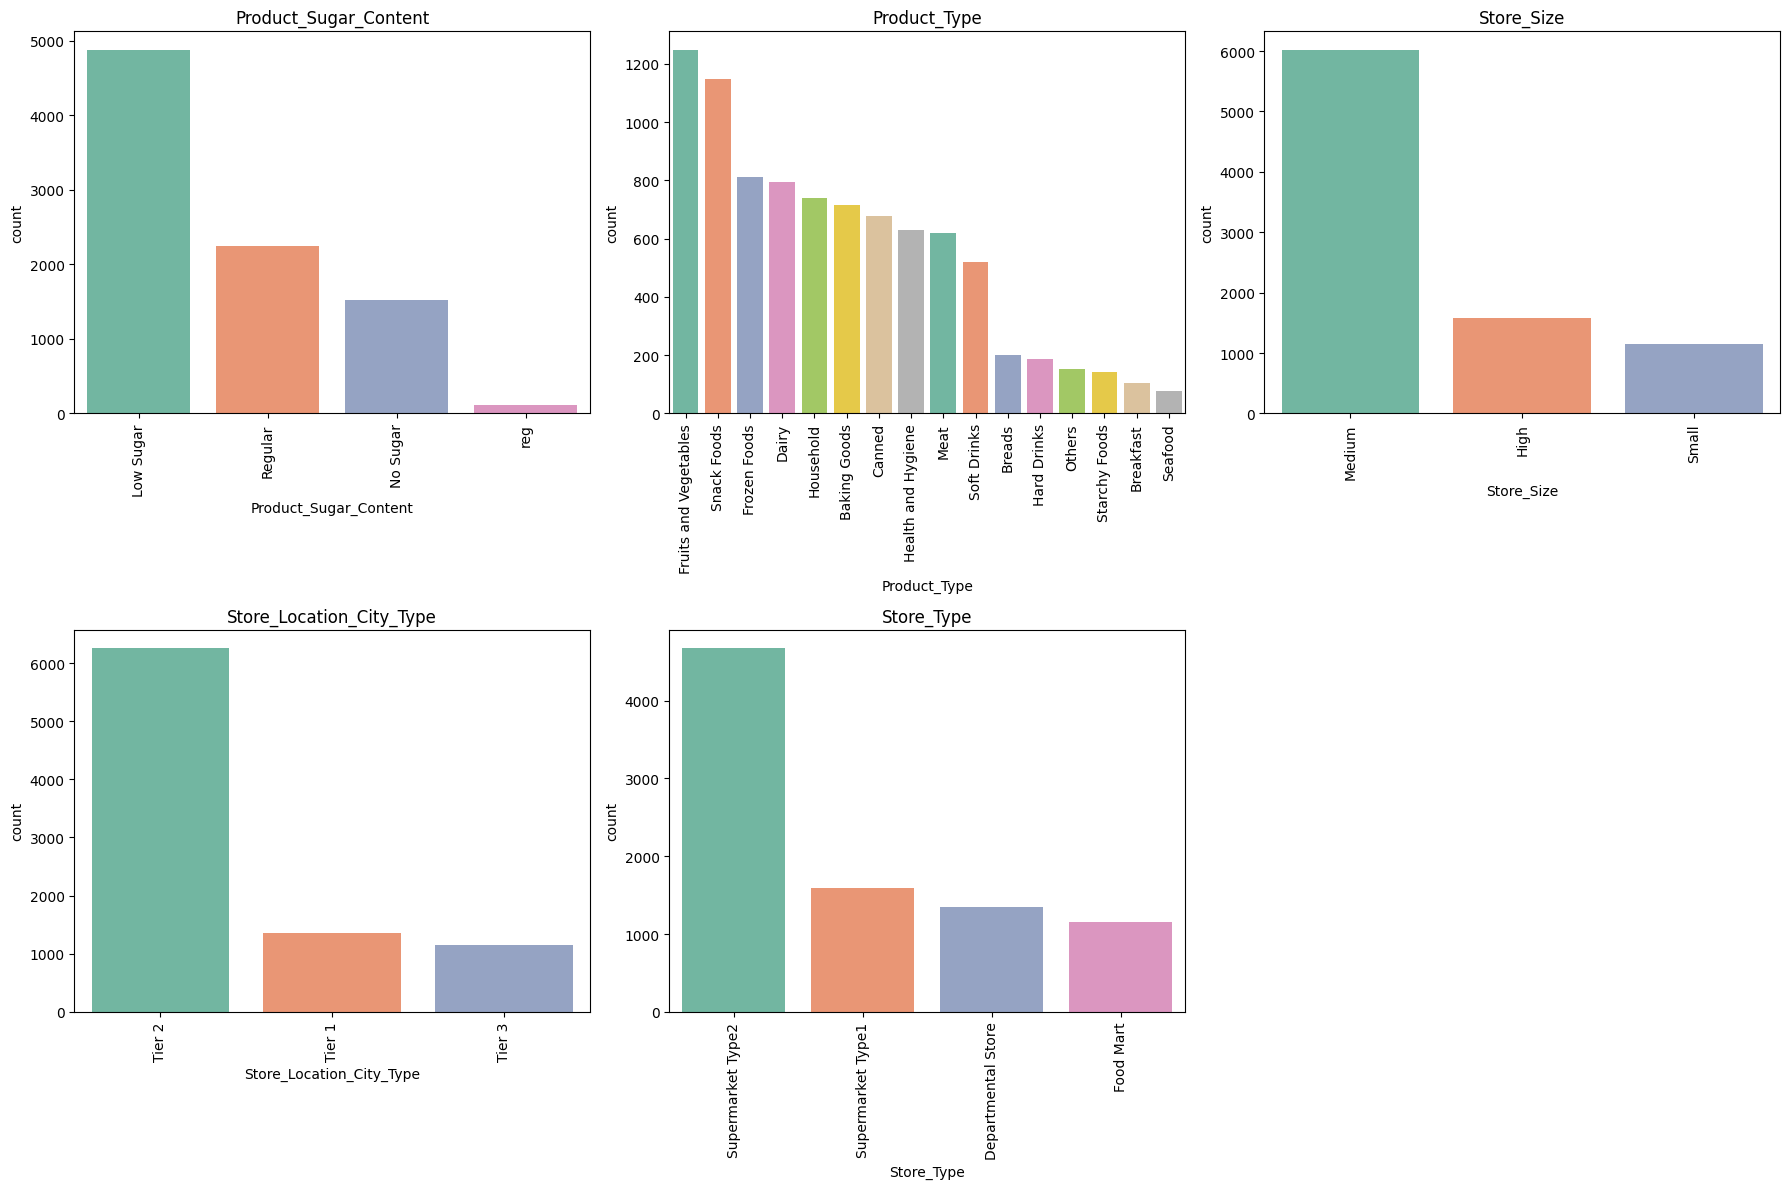

In [136]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for i, feature in enumerate(categorical_features):

    order = data[feature].value_counts().index

    sns.countplot(
        data=data,
        x=feature,
        order=order,
        palette='Set2',
        ax=axes[i]
    )

    axes[i].set_title(f'{feature}', fontsize=12)
    axes[i].tick_params(axis='x', rotation=90)

# Hide unused subplot(s)
for j in range(len(categorical_features), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


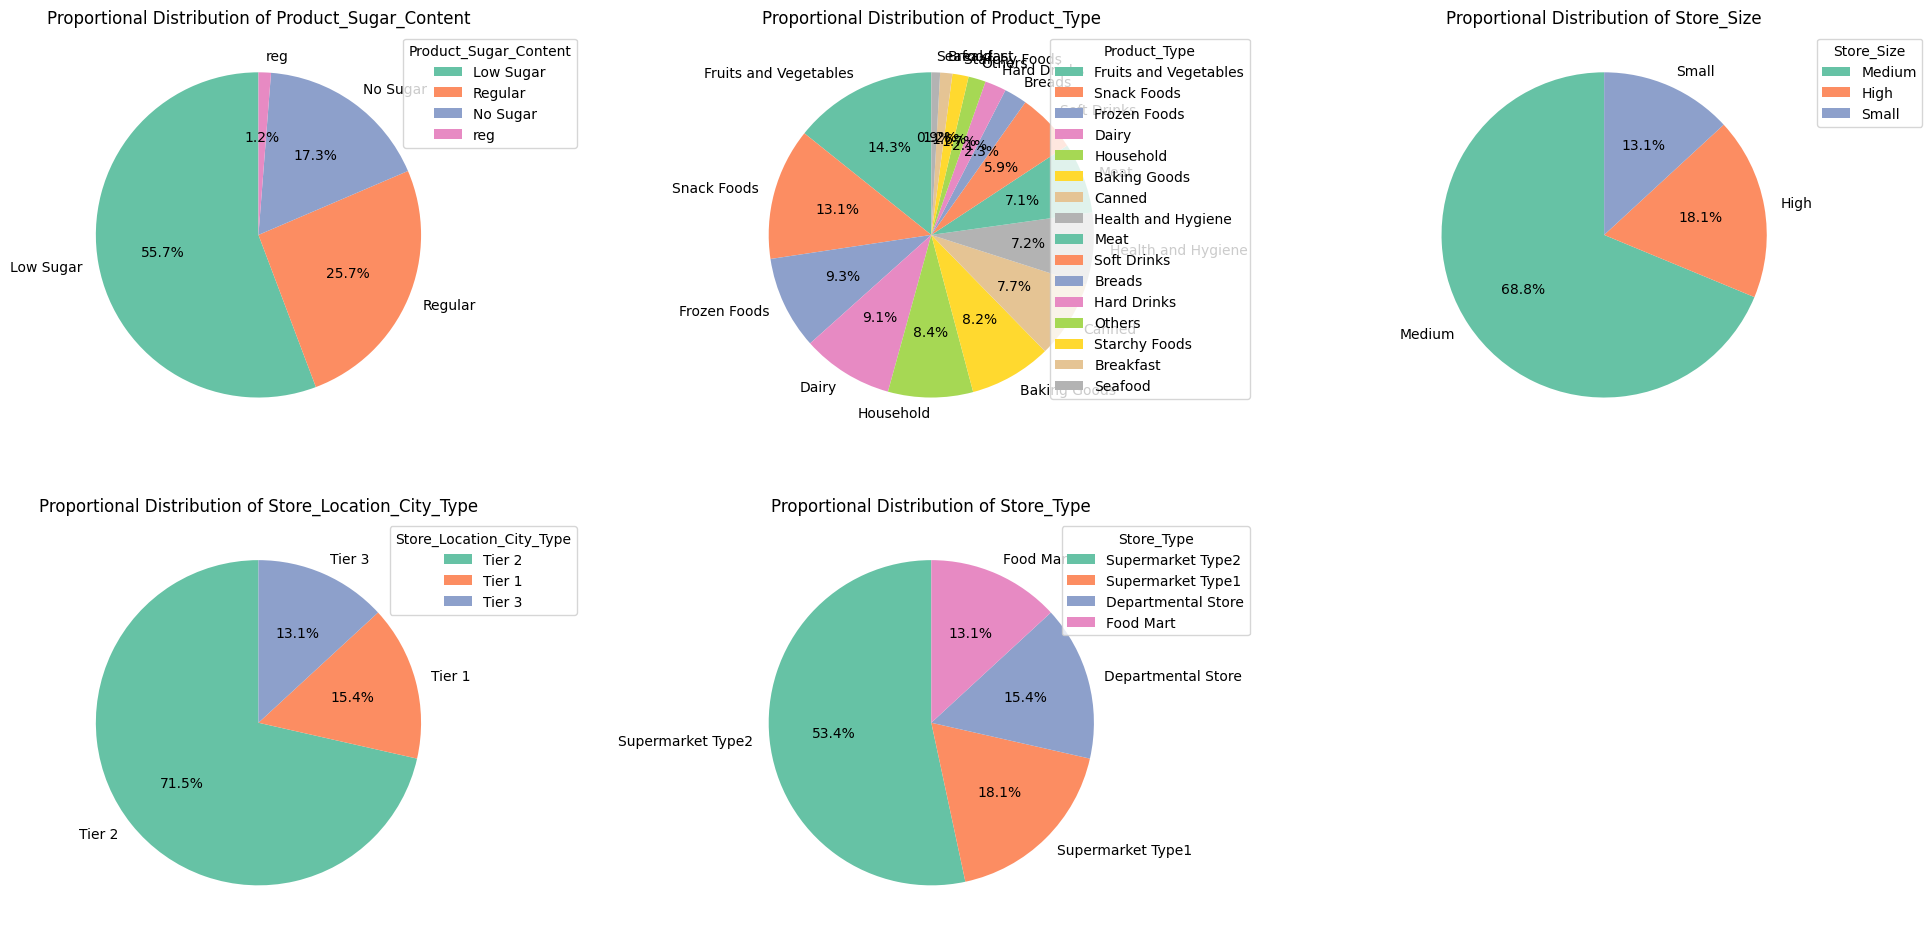

In [137]:
# defining the figure size
plt.figure(figsize=(20, 10))

# plotting the histogram for each numerical feature
for i, feature in enumerate(categorical_features):
    plt.subplot(2, 3, i+1)    # assign a subplot in the main plot
    plt.pie(data[feature].value_counts(), labels=data[feature].value_counts().index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette("Set2"))
    plt.title(f"Proportional Distribution of {feature}")
    plt.legend(title=feature, loc="upper right", bbox_to_anchor=(1.3, 1)) 

plt.tight_layout(pad=3); 

#### Observation:
- **Product_Sugar_Content:** "Low Sugar" is the dominant category, accounting for 55.7% (4885) of products, followed by "Regular" at 26.9% (2251) and "No Sugar" at 17.3% (1515).
- **Product_Type:** "Fruits and Vegetables" (1249) and "Snack Foods" (1200+) are the most common product categories, while "Seafood" (<100) and "Breakfast" (~110) have the lowest representation.
- **Store_Size:** Medium-sized stores account for 68.8% (6025) of observations, compared to 18.1% (1592) for High-sized stores and 13.1% (1146) for Small-sized stores.
- **Store_Location_City_Type:** Tier 2 cities contribute 71.5% (6262) of all records, whereas Tier 1 and Tier 3 cities account for 15.4% (1348) and 13.1% (1153), respectively.
- **Store_Type:** Supermarket Type2 is the most prevalent store format, representing 53.4% (4676) of observations, while Supermarket Type1 (18.1%), Departmental Store (15.4%), and Food Mart (13.1%) have relatively smaller shares.
- **Product_Type_Category:** Non-Perishables make up 65.3% of products, while Perishables account for the remaining 34.7%, indicating a higher concentration of non-perishable items.
- **Product_Id_char:** Products with the "FD" prefix dominate the dataset at 74.6% (6539), followed by "NC" at 17.3% (1519) and "DR" at 8.0% (705).

### Analyzing Numerical Features

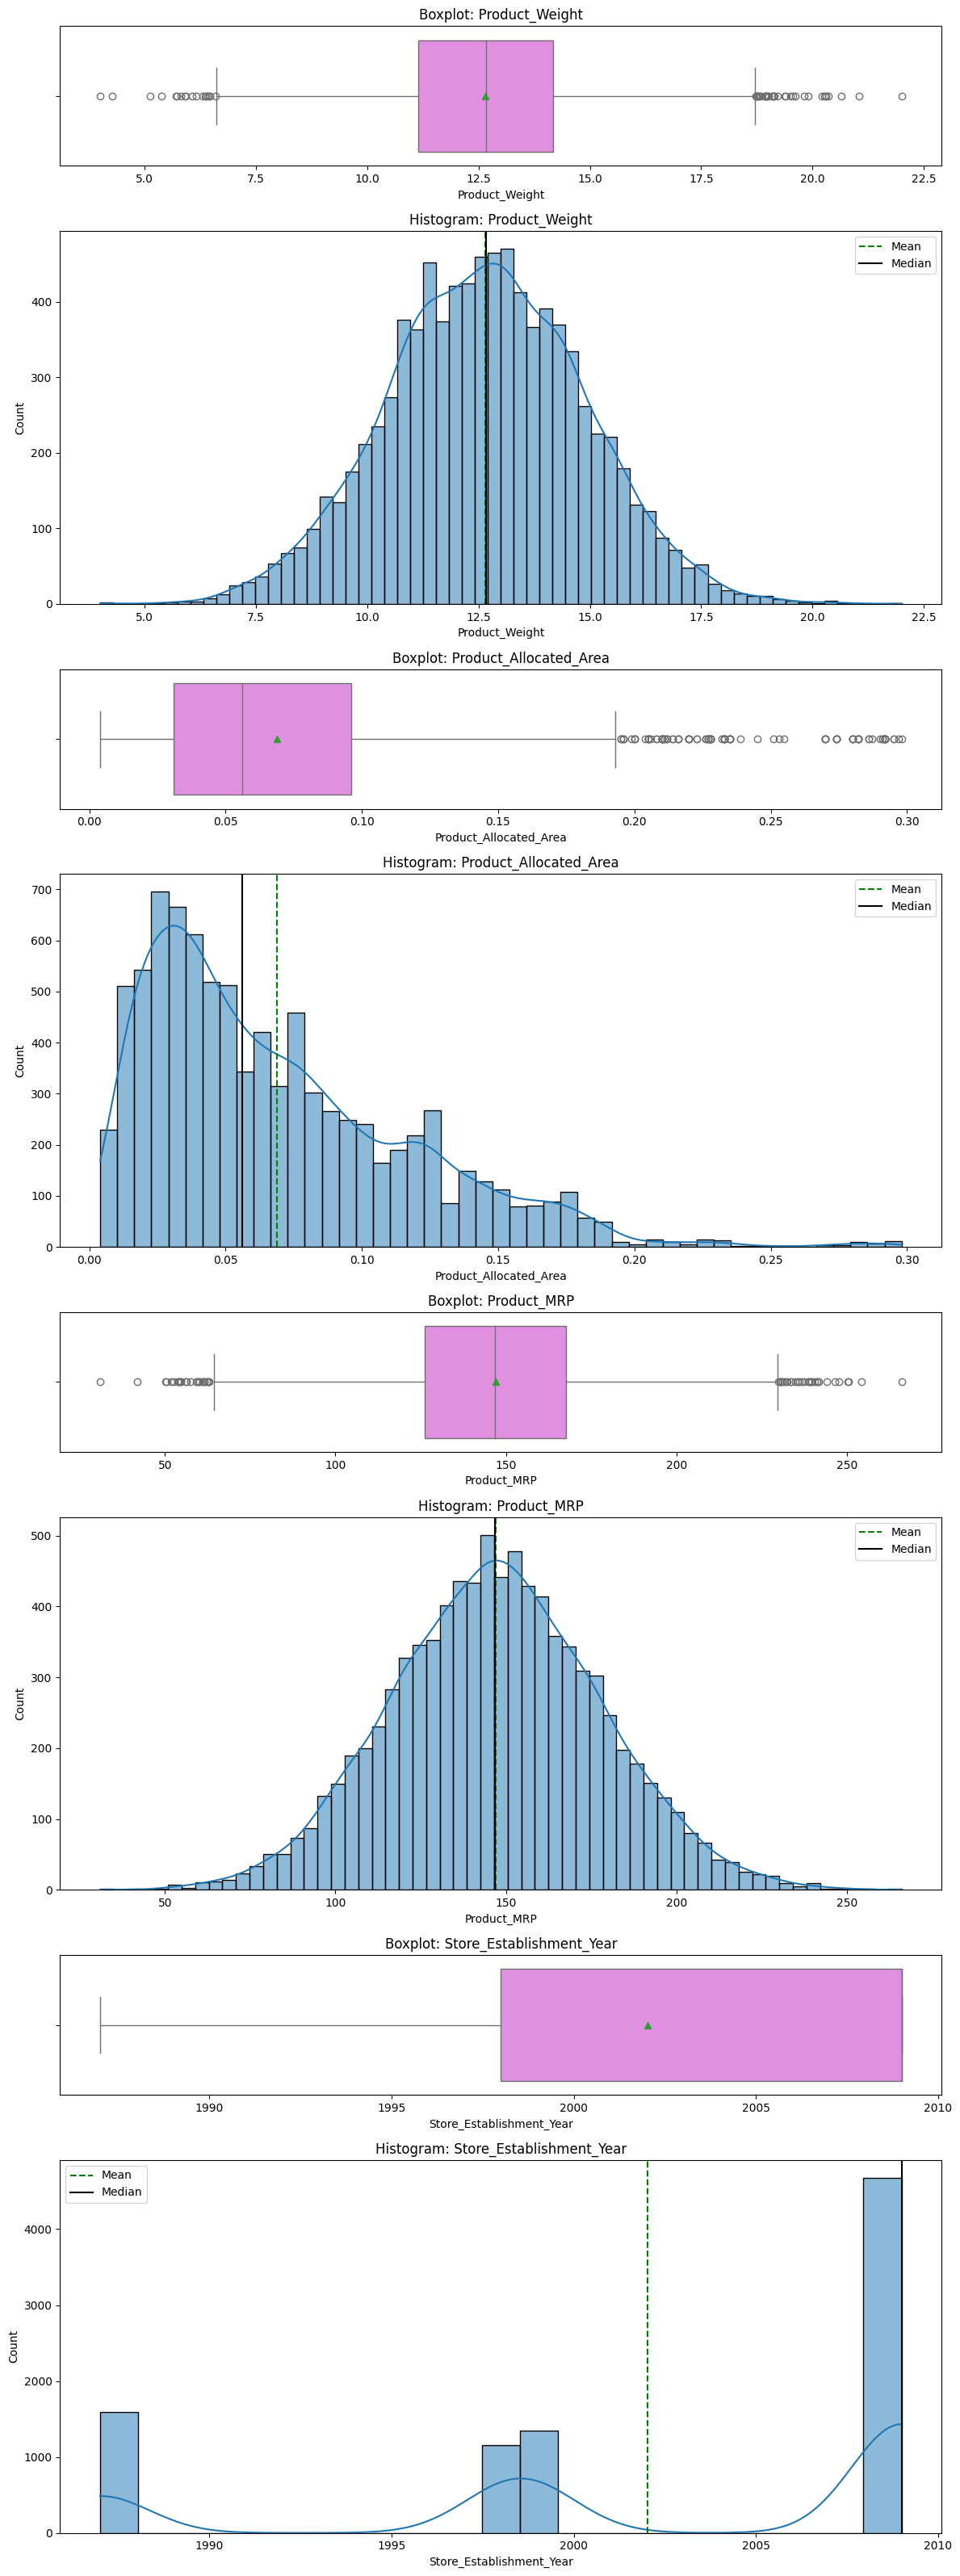

In [138]:
fig, axes = plt.subplots(
    len(numeric_features) * 2, 1,
    figsize=(12, 8 * len(numeric_features)),
    gridspec_kw={'height_ratios': [0.75, 2] * len(numeric_features)})

for i, col in enumerate(numeric_features):
    sns.boxplot(data=data, x=col, ax=axes[2*i], color='violet', showmeans=True)
    sns.histplot(data=data, x=col, kde=True, ax=axes[2*i+1])

    axes[2*i+1].axvline(data[col].mean(), color='green', linestyle='--', label='Mean')
    axes[2*i+1].axvline(data[col].median(), color='black', label='Median')

    axes[2*i].set_title(f'Boxplot: {col}')
    axes[2*i+1].set_title(f'Histogram: {col}')
    axes[2*i+1].legend()

plt.tight_layout()
plt.show()

#### Observations:
- **Product_Weight:** The distribution is approximately normal, with the mean and median nearly overlapping around 12.6. A small number of observations are present at both lower (~4-7) and higher (~19-22) weight ranges.
- **Product_Allocated_Area:** The distribution is positively skewed, with most products allocated less than 0.10 area units. Several observations extend beyond 0.20, creating a long right tail.
- **Product_MRP:** Product prices exhibit a near-symmetric distribution centred around 147, with most observations concentrated between approximately 120 and 180. A few observations are present at both the lower and higher ends of the price range.
- **Store_Establishment_Year:** The distribution is concentrated around a few distinct years, with 2009 accounting for the largest share of stores. Older establishment years such as 1987 appear much less frequently.
- **Outlier Analysis:** Outliers are visible in `Product_Weight`, `Product_Allocated_Area`, and `Product_MRP`, with `Product_Allocated_Area` showing the highest concentration of extreme values relative to its overall range.

## Bivariate Analysis

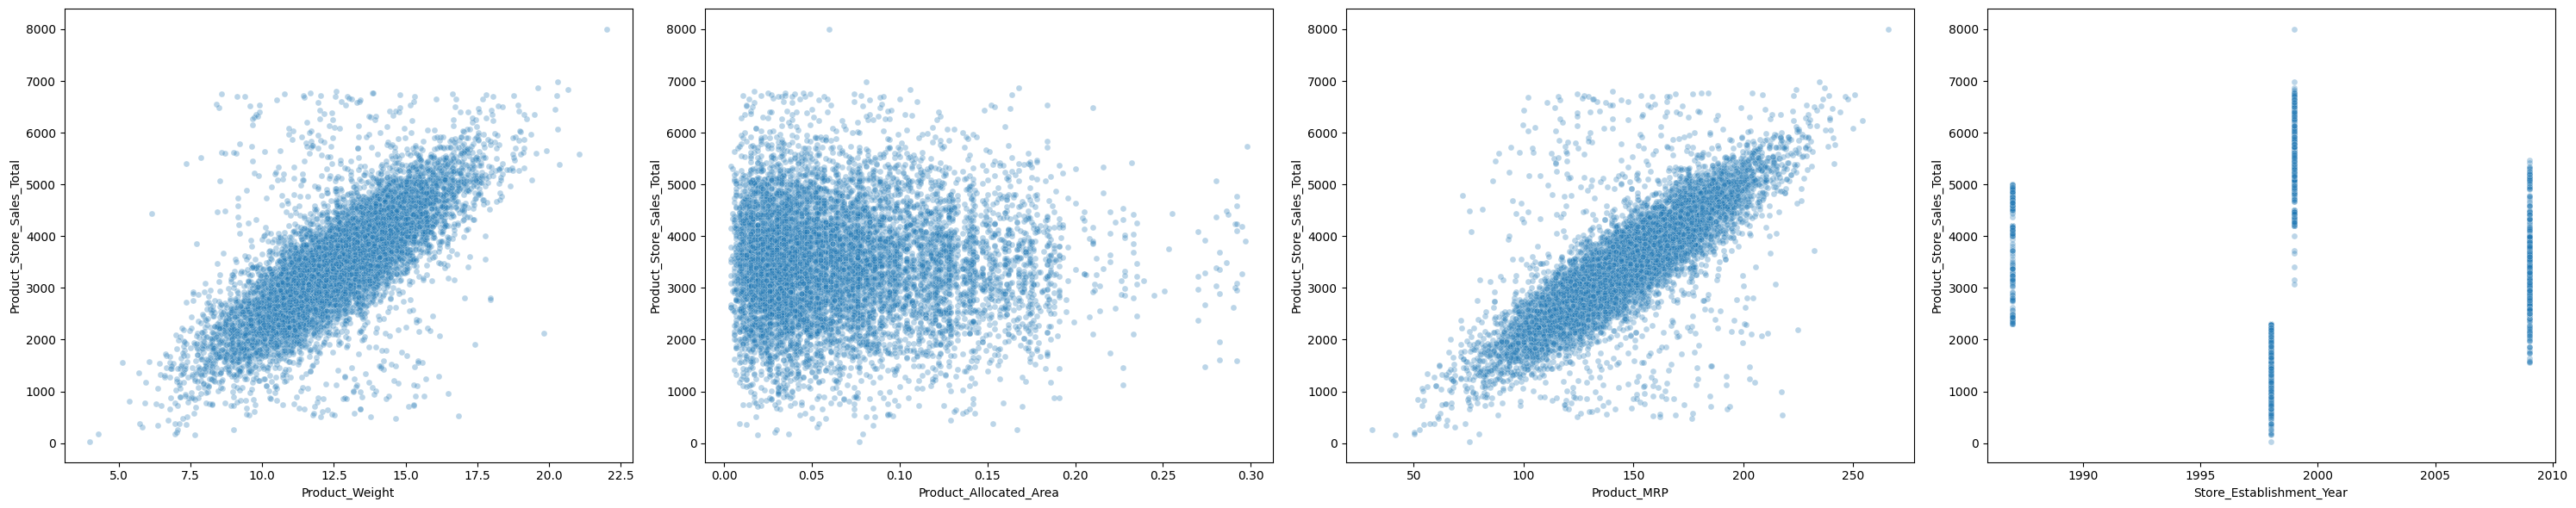

In [139]:
fig, axes = plt.subplots(1, 4, figsize=(30, 6))
for ax, col in zip(axes.ravel(), numeric_features):
    sns.scatterplot(x=data[col], y=data[target], ax=ax, alpha=0.3, s=25)
plt.tight_layout(); plt.show()

#### Observations:
- Product_MRP exhibits the strongest positive relationship with Product_Store_Sales_Total, with sales increasing consistently as MRP increases.
- Product_Weight also shows a positive association with Product_Store_Sales_Total, with higher sales concentrated for products weighing approximately 10 to 17 units.
- Product_Allocated_Area and Store_Establishment_Year display weak relationships with Product_Store_Sales_Total, as sales remain widely distributed across their respective value ranges.

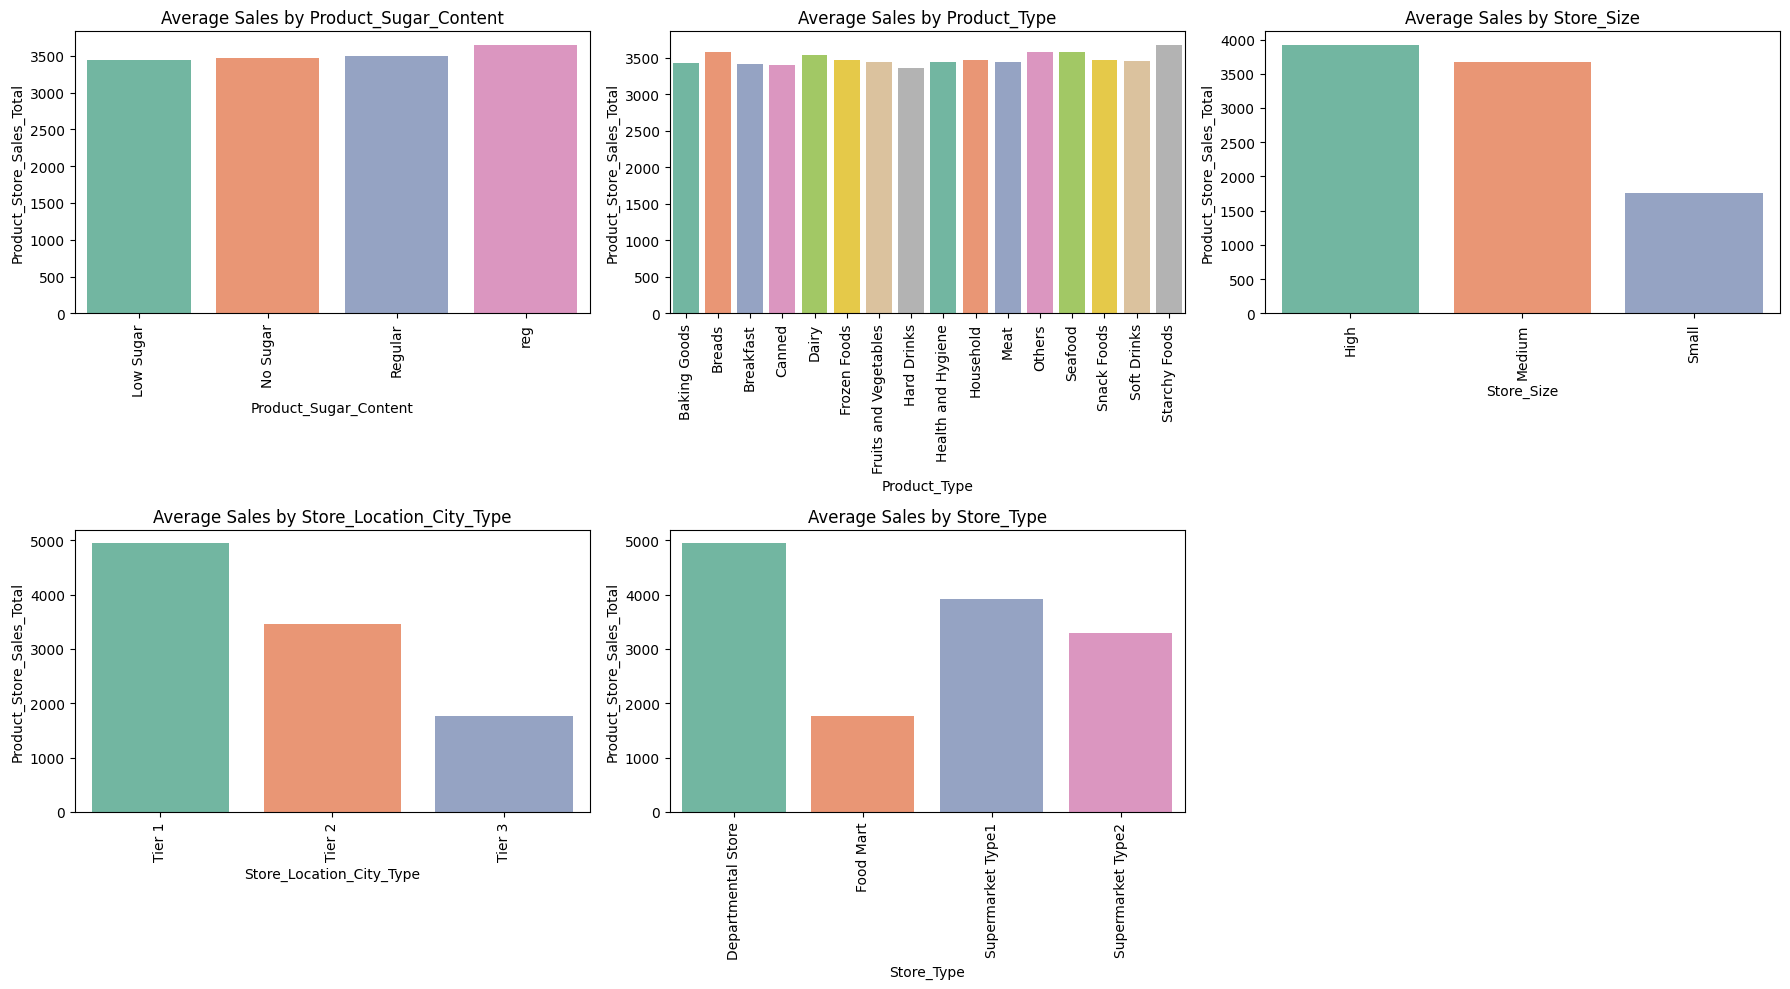

In [140]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, col in enumerate(categorical_features):
    avg_sales = (data.groupby(col)[target].mean().sort_values(ascending=False).reset_index())
    sns.barplot(data=avg_sales,x=col,y=target,palette='Set2',ax=axes[i])
    axes[i].tick_params(axis='x', rotation=90)
    axes[i].set_title(f'Average Sales by {col}')
# Hide unused subplot
for j in range(len(categorical_features), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


In [141]:
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.ravel()

for i, col in enumerate(categorical_features):
    order = (data.groupby(col)[target].median().sort_values().index)
    sns.boxplot(data=data,x=col,y=target,order=order,palette='Set2',width=0.7, ax=axes[i])s
    axes[i].set_title(f'{col} vs {target}')
    axes[i].tick_params(axis='x', rotation=45)

# Hide unused subplot(s)
for j in range(len(categorical_features), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

SyntaxError: invalid syntax (3290801841.py, line 6)

#### Observations:
- Product_Sugar_Content categories show very similar sales distributions, with median sales concentrated around 3,400 to 3,700 and only minor variation across categories.
- Product_Type categories exhibit substantial overlap in sales performance, with median sales generally ranging between 3,200 and 3,800, while several categories contain outliers reaching 6,500 to 8,000.
- Store_Size demonstrates a strong association with sales, with median sales increasing from approximately 1,900 for Small stores to 3,500 for Medium stores and 4,100 for High-sized stores.
- Store_Location_City_Type shows a clear tier-wise increase in sales, with median sales of approximately 1,900 for Tier 3, 3,400 for Tier 2, and 4,900 for Tier 1 stores.
- Store_Type displays the largest variation in sales levels, with median sales increasing from approximately 1,900 for Food Mart to 3,300 for Supermarket Type2, 4,100 for Supermarket Type1, and 5,000 for Departmental Stores; maximum sales reach approximately 8,000.

In [ ]:
# Mean/median sales per category
for col in categorical_features:
    print(f'\n--- {col} ---')
    print(data.groupby(col)[target].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False))

#### Observations:
- Product_Sugar_Content shows limited variation in sales, with mean sales ranging from 3,443.89 (Low Sugar) to 3,648.55 (reg) despite substantial differences in category counts (108 to 4,885 records).
- Product_Type categories exhibit relatively similar sales performance, with mean sales ranging from 3,364.59 (Hard Drinks) to 3,679.25 (Starchy Foods), a difference of approximately 315 units.
- Store-related categories display much larger sales variation than product-related categories, with mean sales ranging from 1,762.94 for Small Stores, Tier 3 locations, and Food Marts to 4,946.97 for Tier 1 locations and Departmental Stores.


## Multivariate Analysis

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(data[numeric_features + [target]].corr(), annot=True, cmap='viridis',
            fmt='.2f', center=0)
plt.title('Numeric correlation matrix'); plt.show()

#### Observations:
- `Product_Store_Sales_Total` has a strong positive correlation with Product_MRP (0.79) and Product_Weight (0.74), indicating sales tend to increase with both variables.
- `Product_Allocated_Area` shows virtually no relationship with sales (r ≈ 0.00), suggesting negligible linear association with Product_Store_Sales_Total.
- `Store_Establishment_Year` exhibits a weak negative correlation with sales (r = -0.19), while Product_MRP and Product_Weight are moderately correlated with each other (r = 0.53).

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

for i, (ax, col) in enumerate(zip(axes.ravel(), numeric_features)):
    sns.scatterplot(data=data,x=col,y=target,hue='Store_Location_City_Type',alpha=0.3,s=25,ax=ax)
    ax.set_title(f'{col} vs {target}')
    # Remove legend from all plots except first
    if i != 0:
        ax.get_legend().remove()

# Get handles & labels from first plot
handles, labels = axes[0].get_legend_handles_labels()
axes[0].get_legend().remove()

# Put one legend outside
fig.legend(handles,labels,title='Store_Location_City_Type',bbox_to_anchor=(1.02, 1),loc='center left')bb
plt.tight_layout()
plt.show()

#### Observations:
- `Product_MRP` and `Product_Weight` show clear positive relationships with sales across all city tiers, with Tier 1 stores consistently achieving the highest sales levels and Tier 3 stores the lowest.
- `Product_Allocated_Area` exhibits little visible relationship with sales, as sales remain broadly distributed across the entire allocated area range within each city tier.
- `Store_Location_City_Type` forms distinct sales clusters, with Tier 1 sales concentrated around 4,500–6,000, Tier 2 around 2,500–4,500, and Tier 3 around 1,000–2,500, indicating strong separation by location tier.

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

for i, (ax, col) in enumerate(zip(axes.ravel(), numeric_features)):
    sns.scatterplot(data=data,x=col,y=target,hue='Store_Type',alpha=0.3,s=25,ax=ax)
    ax.set_title(f'{col} vs {target}')
    # Remove legend from all plots except first
    if i != 0:
        ax.get_legend().remove()
# Get handles & labels from first plot
handles, labels = axes[0].get_legend_handles_labels()
axes[0].get_legend().remove()

# Put one legend outside
fig.legend(handles,labels,title='Store_Type',bbox_to_anchor=(1.02, 1),loc='center left')

plt.tight_layout()
plt.show()

#### Observation:
- Store types form distinct sales clusters, with Departmental Stores showing the highest sales range (approximately 4,000–8,000) and Food Marts the lowest (approximately 500–2,500), while Product_Allocated_Area shows no clear relationship with sales.

In [ ]:
# Heatmap of mean sales across two categorical dimensions
pivot = data.pivot_table(values=target, index='Store_Type',
                       columns='Store_Size', aggfunc='mean')
plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title(f'Mean {target}: Store_Type x Store_Size'); plt.show()

#### Observations:
- Average sales increase substantially across store-type and store-size combinations, from 1,763 for Food Mart (Small) to 4,947 for Departmental Store (Medium).
- Departmental Store (4,947) records the highest average sales, followed by Supermarket Type1 (3,924) and Supermarket Type2 (3,299), indicating clear variation in sales performance across store formats.

### Let's view the total sales revenue by Product Type per Store

In [ ]:
# Generate table displaying total sales revenue by Product Type per Store
pivot_sales_revenue = data.pivot_table(
    index='Product_Type',
    columns='Store_Id',
    values='Product_Store_Sales_Total',
    aggfunc='sum',
    fill_value=0
)

pivot_sales_revenue = pivot_sales_revenue.sort_values(by=pivot_sales_revenue.columns.tolist(), ascending=False)
display(pivot_sales_revenue)

#### Observation 
- Sales patterns are broadly consistent across all Store_Id categories, with the same product categories (such as Snack Foods and Fruits and Vegetables) contributing the highest sales and lower-volume categories (such as Breakfast and Seafood) contributing the lowest, indicating that Store_Id largely reflects underlying store characteristics already captured by other store-related features.

# **Data Preprocessing**

### Feature Engineering

### Preprocess `Product_Sugar_Content`
As seen earlier, Product_Sugar_Content column conatins 4 types - "Low Sugar", "Regular", "No Sugar", "reg". Replace "reg" with "Regular"

In [142]:
# Replace reg with Regular
data["Product_Sugar_Content"] = data["Product_Sugar_Content"].replace({"reg": "Regular"})
data['Product_Sugar_Content'] = (data['Product_Sugar_Content'].cat.remove_unused_categories())

In [143]:
print(data["Product_Sugar_Content"].nunique())
data["Product_Sugar_Content"].value_counts()

3


Product_Sugar_Content
Low Sugar    4885
Regular      2359
No Sugar     1519
Name: count, dtype: int64

#### Observations:
- After consolidating "reg" into "Regular", the category distribution becomes cleaner, with Low Sugar remaining the dominant category (4,885 records), followed by Regular (2,359 records) and No Sugar (1,519 records).

### Store's Age

- The Store_Establishment_Year column contains four unique values: 1987, 1999, 1998, and 2009. 
- The dataset shows a higher frequency of more recently established stores. 
- To incorporate the potential influence of a store's age on sales for modeling, we will calculate the Store_Age_Years."

In [144]:
# Store Age
data["Store_Age_Years"] = 2026 - data.Store_Establishment_Year

In [145]:
data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Store_Age_Years
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40,17
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02,27
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16,39
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18,39
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36,28


#### Observations:
- `Store_Age_Years` column has been reflecting with store age, making sense and easy to interpret

### Feature Grouping : `Product_Type`

- There are 16 different product types in our dataset.
- To reduce dimensionality and potentially capture broader patterns, we will perform feature binning by grouping these types into two main categories: Perishables and Non-Perishables.

In [146]:
data["Product_Type"].unique().tolist()

['Frozen Foods',
 'Dairy',
 'Canned',
 'Baking Goods',
 'Health and Hygiene',
 'Snack Foods',
 'Meat',
 'Household',
 'Hard Drinks',
 'Fruits and Vegetables',
 'Breads',
 'Soft Drinks',
 'Breakfast',
 'Others',
 'Starchy Foods',
 'Seafood']

In [147]:
perishables = [
    "Dairy",
    "Meat",
    "Fruits and Vegetables",
    "Breakfast",
    "Breads",
    "Seafood",
]

In [148]:
def change(x):
    if x in perishables:
        return "Perishables"
    else:
        return "Non Perishables"

In [149]:
data['Product_Type_Category'] = data['Product_Type'].apply(change)

In [150]:
data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Store_Age_Years,Product_Type_Category
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40,17,Non Perishables
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02,27,Perishables
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16,39,Non Perishables
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18,39,Non Perishables
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36,28,Non Perishables


#### Observations:
- Product types were consolidated into two broader groups: Perishable (Dairy, Meat, Fruits and Vegetables, Breakfast, Breads, and Seafood) and Non-Perishable (all remaining product categories), reducing category complexity from 16 categories to 2 categories.

### Extracting Two Letter Pattern from Product_ID

In [151]:
data["Product_Id"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 8763 entries, 0 to 8762
Series name: Product_Id
Non-Null Count  Dtype   
--------------  -----   
8763 non-null   category
dtypes: category(1)
memory usage: 343.7 KB


In [152]:
# Extract the first two characters from the Product_Id column and store it in a new column
data["Product_Id_char"] = data["Product_Id"].str[:2]
data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Store_Age_Years,Product_Type_Category,Product_Id_char
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40,17,Non Perishables,FD
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02,27,Perishables,FD
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16,39,Non Perishables,FD
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18,39,Non Perishables,FD
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36,28,Non Perishables,NC


In [153]:
data["Product_Id_char"].value_counts()

Product_Id_char
FD    6539
NC    1519
DR     705
Name: count, dtype: int64

In [154]:
display(data.loc[data.Product_Id_char == "FD", "Product_Type"].unique())
display(data.loc[data.Product_Id_char == "NC", "Product_Type"].unique())
display(data.loc[data.Product_Id_char == "DR", "Product_Type"].unique())

['Frozen Foods', 'Dairy', 'Canned', 'Baking Goods', 'Snack Foods', ..., 'Fruits and Vegetables', 'Breads', 'Breakfast', 'Starchy Foods', 'Seafood']
Length: 11
Categories (16, object): ['Baking Goods', 'Breads', 'Breakfast', 'Canned', ..., 'Seafood', 'Snack Foods', 'Soft Drinks', 'Starchy Foods']

['Health and Hygiene', 'Household', 'Others']
Categories (16, object): ['Baking Goods', 'Breads', 'Breakfast', 'Canned', ..., 'Seafood', 'Snack Foods', 'Soft Drinks', 'Starchy Foods']

['Hard Drinks', 'Soft Drinks']
Categories (16, object): ['Baking Goods', 'Breads', 'Breakfast', 'Canned', ..., 'Seafood', 'Snack Foods', 'Soft Drinks', 'Starchy Foods']

#### Observation -
- Products with IDs starting with 'DR' appear to be drinks, while those with 'NC' prefixes seem to categorize non-consumable items rest FD for Food Items.
- A new feature, Product_Id_char, was derived from the product ID prefix, categorising products into Food Items (FD: 6,539 records), Non-Consumables (NC: 1,519 records), and Drinks (DR: 705 records), with Food Items representing the majority (74.6%) of observations.

## Final Preprocessing

### Checking class imbalance

In [155]:
# Loop through all selected categorical features
# and print the percentage distribution of each category
for col in categorical_features:
    print(f"\nColumn: {col}")
    print(data[col].value_counts(normalize=True).round(3) * 100)


Column: Product_Sugar_Content
Product_Sugar_Content
Low Sugar    55.7
Regular      26.9
No Sugar     17.3
Name: proportion, dtype: float64

Column: Product_Type
Product_Type
Fruits and Vegetables    14.3
Snack Foods              13.1
Frozen Foods              9.3
Dairy                     9.1
Household                 8.4
Baking Goods              8.2
Canned                    7.7
Health and Hygiene        7.2
Meat                      7.1
Soft Drinks               5.9
Breads                    2.3
Hard Drinks               2.1
Others                    1.7
Starchy Foods             1.6
Breakfast                 1.2
Seafood                   0.9
Name: proportion, dtype: float64

Column: Store_Size
Store_Size
Medium    68.8
High      18.1
Small     13.1
Name: proportion, dtype: float64

Column: Store_Location_City_Type
Store_Location_City_Type
Tier 2    71.5
Tier 1    15.4
Tier 3    13.1
Name: proportion, dtype: float64

Column: Store_Type
Store_Type
Supermarket Type2     53.4
Supermar

#### Observation - 
- While some categorical features such as Product_Sugar_Content, Store_Size, and Store_Location_City_Type exhibit moderate class imbalance, none are extreme enough to warrant resampling or weighting adjustments in the modeling phase.
- I believe this distribution is acceptable for model training without additional correction.

### Check for Outliers and Skewness (Numerical Features)

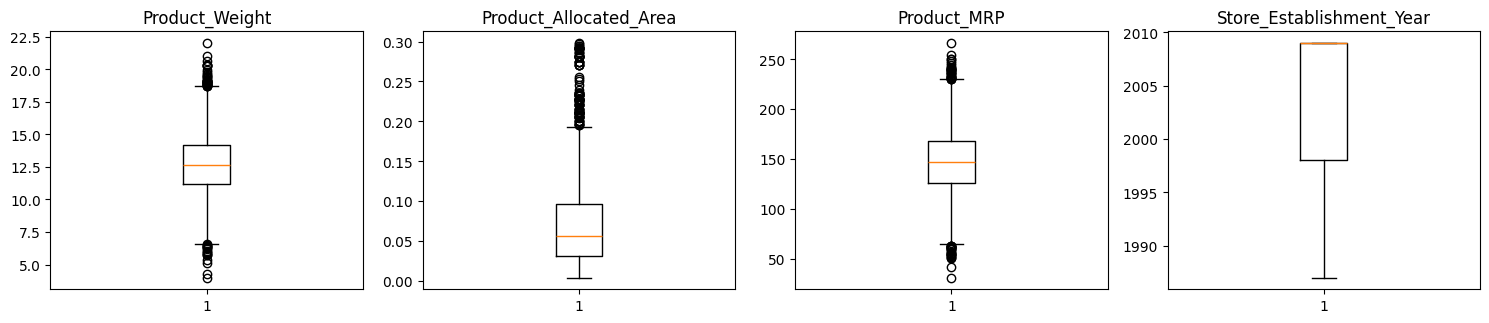

In [156]:
plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_features):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

#### Observation
- Outliers were observed in Product_Weight, Product_Allocated_Area, and Product_MRP during univariate analysis.
- These outliers continuously and coherently extended from the whiskers in the boxplots
- Hence, no specific outlier treatment will be performed, and the full dataset will be utilized for model building.

### **Dropping the following redundant columns:**
- `Product_Id` as the encoded information is extracted into `Product_Id_char`
- `Store_Id`, due to its one-to-one mapping with `Store_Type`.
- `Product_Type`, as it has been binned into `Product_Type_Category`.
- `Store_Establishment_Year`, as its information is now represented by `Store_Age_Years`.

In [157]:
data[["Product_Type_Category", "Product_Id_char"]].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Product_Type_Category  8763 non-null   object
 1   Product_Id_char        8763 non-null   object
dtypes: object(2)
memory usage: 137.0+ KB


In [158]:
columns = ["Product_Type_Category", "Product_Id_char"]
for column in columns:
    data[column] = data[column].astype("category")

In [159]:
data.columns.tolist()

['Product_Id',
 'Product_Weight',
 'Product_Sugar_Content',
 'Product_Allocated_Area',
 'Product_Type',
 'Product_MRP',
 'Store_Id',
 'Store_Establishment_Year',
 'Store_Size',
 'Store_Location_City_Type',
 'Store_Type',
 'Product_Store_Sales_Total',
 'Store_Age_Years',
 'Product_Type_Category',
 'Product_Id_char']

In [160]:
data.drop(["Product_Id", "Store_Id", "Product_Type", "Store_Establishment_Year"], axis=1, inplace=True)

In [161]:
data.columns.tolist()

['Product_Weight',
 'Product_Sugar_Content',
 'Product_Allocated_Area',
 'Product_MRP',
 'Store_Size',
 'Store_Location_City_Type',
 'Store_Type',
 'Product_Store_Sales_Total',
 'Store_Age_Years',
 'Product_Type_Category',
 'Product_Id_char']

In [162]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   Product_Weight             8763 non-null   float64 
 1   Product_Sugar_Content      8763 non-null   category
 2   Product_Allocated_Area     8763 non-null   float64 
 3   Product_MRP                8763 non-null   float64 
 4   Store_Size                 8763 non-null   category
 5   Store_Location_City_Type   8763 non-null   category
 6   Store_Type                 8763 non-null   category
 7   Product_Store_Sales_Total  8763 non-null   float64 
 8   Store_Age_Years            8763 non-null   int64   
 9   Product_Type_Category      8763 non-null   category
 10  Product_Id_char            8763 non-null   category
dtypes: category(6), float64(4), int64(1)
memory usage: 394.6 KB


- Unneeded columns has been dropped

In [163]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Product_Weight,8763.0,12.653792,2.217320,4.000,11.150,12.660,14.180,22.000
Product_Allocated_Area,8763.0,0.068786,0.048204,0.004,0.031,0.056,0.096,0.298
Product_MRP,8763.0,147.032539,30.694110,31.000,126.160,146.740,167.585,266.000
Product_Store_Sales_Total,8763.0,3464.003640,1065.630494,33.000,2761.715,3452.340,4145.165,8000.000
Store_Age_Years,8763.0,23.967249,8.388381,17.000,17.000,17.000,28.000,39.000


In [164]:
data.describe(include='category').T

,count,unique,top,freq
Product_Sugar_Content,8763,3,Low Sugar,4885
Store_Size,8763,3,Medium,6025
Store_Location_City_Type,8763,3,Tier 2,6262
Store_Type,8763,4,Supermarket Type2,4676
Product_Type_Category,8763,2,Non Perishables,5718
Product_Id_char,8763,3,FD,6539


In [165]:
data.head()

,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_MRP,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Store_Age_Years,Product_Type_Category,Product_Id_char
0,12.66,Low Sugar,0.027,117.08,Medium,Tier 2,Supermarket Type2,2842.40,17,Non Perishables,FD
1,16.54,Low Sugar,0.144,171.43,Medium,Tier 1,Departmental Store,4830.02,27,Perishables,FD
2,14.28,Regular,0.031,162.08,High,Tier 2,Supermarket Type1,4130.16,39,Non Perishables,FD
3,12.10,Low Sugar,0.112,186.31,High,Tier 2,Supermarket Type1,4132.18,39,Non Perishables,FD
4,9.57,No Sugar,0.010,123.67,Small,Tier 3,Food Mart,2279.36,28,Non Perishables,NC


- Data quality checks and feature engineering outputs are consistent with expectations, with categorical consolidations and derived features successfully applied and validated.
- The final dataset contains cleaned and transformed features with expected distributions and is ready for train-test splitting for model development.

## Splitting the Data for Train and Test (80:20)

An 80:20 split provides a balanced trade-off between model training and evaluation, ensuring sufficient data for learning while retaining an independent sample for performance assessment.

- Target column is Product_Store_Sales_Total
- Split the data into training and testing sets

In [166]:
# Separate predictors and the target column
X = data.drop("Product_Store_Sales_Total", axis=1)
y = data["Product_Store_Sales_Total"]

In [167]:
X.shape, y.shape

((8763, 10), (8763,))

In [168]:
# Split the data into train and test sets in 70:30 ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, shuffle=True
)

In [169]:
X_train.shape, X_test.shape

((7010, 10), (1753, 10))

- The dataset was split using an 80:20 ratio, resulting in 7,010 training records (80.0%) and 1,753 test records (20.0%), with both datasets containing 10 features.

In [170]:
X_train.head()

,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_MRP,Store_Size,Store_Location_City_Type,Store_Type,Store_Age_Years,Product_Type_Category,Product_Id_char
7361,11.68,Regular,0.044,141.82,Medium,Tier 2,Supermarket Type2,17,Non Perishables,FD
54,11.81,Low Sugar,0.100,180.62,Medium,Tier 2,Supermarket Type2,17,Non Perishables,DR
4133,13.23,Low Sugar,0.061,127.23,Medium,Tier 2,Supermarket Type2,17,Non Perishables,FD
7011,15.51,Regular,0.073,170.86,High,Tier 2,Supermarket Type1,39,Non Perishables,DR
4230,11.71,Low Sugar,0.085,151.65,Medium,Tier 2,Supermarket Type2,17,Perishables,FD


## Data Pre-Processing Pipeline

In [171]:
numerical_features = X.select_dtypes(include=['number']).columns.tolist()
numerical_features

['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Age_Years']

In [172]:
categorical_features = data.select_dtypes(include=['category']).columns.tolist()
categorical_features

['Product_Sugar_Content',
 'Store_Size',
 'Store_Location_City_Type',
 'Store_Type',
 'Product_Type_Category',
 'Product_Id_char']

- Based on the statistical description of the data, the numerical features such as `Product_Weight`, `Product_Allocated_Area`, `Product_MRP`, and `Store_Age_Years` have vastly different scales and ranges.
- For example, `Product_Allocated_Area` ranges from approximately 0.004 to 0.298, while Product_MRP ranges from 31 to 266, and Product_Weight from 4 to 22.
- Standardizing these features by transforming them to have a mean of 0 and a standard deviation of 1 ensures that no single feature dominates the model's learning process solely due to its larger magnitude.

In [173]:
preprocessor = make_column_transformer(
    (StandardScaler(), numerical_features),
    (OneHotEncoder(handle_unknown='ignore'), categorical_features)
)

#### Observation:
- Numerical features were standardised using StandardScaler, while categorical features were transformed using One-Hot Encoding, creating a unified preprocessing pipeline for both feature types.
- The encoder was configured with handle_unknown='ignore', allowing unseen categorical values in the test or inference data to be processed without errors.

# **Model Building**

Metrics Measured for Regression Models -

- R-squared (R²) - Proportion of variance in the target that is predictable from the independent variables. An R-squared value close to 1 indicates that a large proportion of the variance is explained by the model, while a value close to 0 suggests little explanatory power. Generally the first metric to look at for regression model performance.
- Adjusted R-squared - R² adjusted for number of predictors to penalize unnecessary variables. Helps compare models with different numbers of features and avoid overfitting.
- Mean Absolute Error (MAE) - Average absolute difference between predicted and actual values. This metric is intuitive and provides a straightforward way to compare models. A model with a lower MAE is considered better as it indicates smaller prediction errors.
- Root Mean Squared Error (RMSE) - Square root of average squared prediction error. Penalizes large errors heavily; useful when large mistakes are costly.
- Mean Absolute Percentage Error (MAPE) - Express prediction errors as a percentage of the actual values. This normalization allows for comparisons across different scales and datasets.

**Metric Selection**\

R² was selected as the primary evaluation metric because it provides an overall measure of how well the model captures variation in the target variable, making it effective for comparing the explanatory power of multiple regression models. Its scale-independent nature also enables consistent comparison across different model configurations.

## Define functions for Model Evaluation

In [174]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mean_absolute_percentage_error(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

# **Baseline Models**

## Random Forest (Default)

In [175]:
# creating an instance of Random Forest Model
rf_default = RandomForestRegressor(random_state=42)

In [176]:
rf_default = make_pipeline(
    preprocessor,
    rf_default
  )
# Performs preprocessor fit + tranform -> model fit
rf_default.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age_Years']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Type_Category',
                                                   'Product_Id_char'])])),
                ('randomforestregressor',
                 RandomForestRegressor(random_state=42))])

In [177]:
# Check model performance on training set

rf_default_model_train_perf = model_performance_regression(rf_default, X_train, y_train)
rf_default_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,106.463553,40.006492,0.989976,0.989961,0.015096


In [178]:
rf_default_model_test_perf = model_performance_regression(rf_default, X_test, y_test)
rf_default_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,291.223396,110.25475,0.926426,0.926003,0.038455


#### Observations:
- Achieved the highest training performance (R² = 0.9900, RMSE = 106.46) but testing performance declined to R² = 0.9264, RMSE = 291.22, indicating a noticeable train-test gap.
- The large difference between training and testing errors suggests model is over-fitting.


## Gredient Boost (Default)

In [179]:
gbm_default = GradientBoostingRegressor(random_state=42)

In [180]:
gbm_default = make_pipeline(
    preprocessor,
    gbm_default
  )
# Performs preprocessor fit + tranform -> model fit
gbm_default.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age_Years']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Type_Category',
                                                   'Product_Id_char'])])),
                ('gradientboostingregressor',
                 GradientBoostingRegressor(random_state=42))])

In [181]:
# Check model performance on training set
gbm_default_model_train_perf = model_performance_regression(gbm_default, X_train, y_train)
gbm_default_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,289.772786,136.384365,0.925739,0.925632,0.0512


In [182]:
# Check model performance on training set
gbm_default_model_test_perf = model_performance_regression(gbm_default, X_test, y_test)
gbm_default_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,308.199848,145.257723,0.917598,0.917125,0.052636


#### Observations:
- Delivered the consistent train-test behaviour, with R² decreasing from 0.9257 to 0.9176 and RMSE increasing only from 289.77 to 308.20.
- Training and testing error metrics remain closely aligned, indicating stable generalisation.

## XGB Regressor (Default)

In [183]:
xgb_default = XGBRegressor(random_state=42)

In [184]:
xgb_default = make_pipeline(
    preprocessor,
    xgb_default
  )
# Performs preprocessor fit + tranform -> model fit
xgb_default.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age_Years']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Type_Category',
                                                   'Product_Id...
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, random_state=42, ...))])

In [185]:
# Check model performance on training set

xgb_default_model_train_perf = model_performance_regression(xgb_default, X_train, y_train)
xgb_default_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,134.955206,62.047648,0.983893,0.98387,0.021539


In [186]:
# Check model performance on training set

xgb_default_model_test_perf = model_performance_regression(xgb_default, X_test, y_test)
xgb_default_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,302.286727,133.039625,0.920729,0.920274,0.046153


#### Observations:
- Achieved strong training performance (R² = 0.9839, RMSE = 134.96) and test performance (R² = 0.9207, RMSE = 302.29).
- The gap between training and testing performance is smaller than that of Random Forest, indicating better generalisation.
- The difference between train and test metrics suggests the presence of moderate overfitting, though the model retains strong predictive performance on unseen data.

# **Model Performance Improvement - Hyperparameter Tuning**

In [187]:
# Choose r2_score to compare parameter combinations
from sklearn import metrics
scorer = metrics.make_scorer(metrics.r2_score)


## Random Forest (Tuned)

In [188]:
# Instantiate RandomForestRegressor inside pipeline
rf_tuned = make_pipeline(
    preprocessor,
    RandomForestRegressor(random_state=42)
)

In [189]:
# Grid of parameters
parameters = {
    "randomforestregressor__n_estimators": [200, 300, 400],
    "randomforestregressor__max_depth": [3, 4, 5],
    "randomforestregressor__max_features": [0.7, 0.9, 1],
    "randomforestregressor__min_samples_split": [8, 10],
    "randomforestregressor__min_samples_leaf": [2, 3, 4],
    "randomforestregressor__bootstrap": [True]
}

# Run the grid search  (scoring as STRING, not r2_score function)
grid_obj = GridSearchCV(
    rf_tuned,
    parameters,
    scoring=scorer,
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_obj.fit(X_train, y_train)

print("Best Parameters:", grid_obj.best_params_)
print("Best CV R2:", round(grid_obj.best_score_, 4))

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best Parameters: {'randomforestregressor__bootstrap': True, 'randomforestregressor__max_depth': 5, 'randomforestregressor__max_features': 0.9, 'randomforestregressor__min_samples_leaf': 2, 'randomforestregressor__min_samples_split': 10, 'randomforestregressor__n_estimators': 400}
Best CV R2: 0.8982


In [190]:
rf_tuned = grid_obj.best_estimator_
rf_tuned

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age_Years']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Type_Category',
                                                   'Product_Id_char'])])),
                ('randomforestregressor',
                 RandomForestRegressor(max_depth=5, max_features=0.9,
                                       min_samples_leaf=2, min_samples_split=10,
                                       n_estimators=400, random_state=42))])

In [191]:
# Check the model performance on training set
rf_tuned_model_train_perf = model_performance_regression(rf_tuned, X_train, y_train)
rf_tuned_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,328.621599,200.282608,0.904492,0.904355,0.07195


In [192]:
# Check the model performance on test set
rf_tuned_model_test_perf = model_performance_regression(rf_tuned, X_test, y_test)
rf_tuned_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,342.522819,206.393343,0.898222,0.897638,0.07079


#### Observations:
- Model overfitting was reduced, resulting in lower training performance (R² = 0.9045) and testing performance (R² = 0.8982).
- Training and testing metrics became more closely aligned compared to the default model.

## Gradient Boost (Tuned)

In [193]:
# Pipeline
gbm_tuned = make_pipeline(
    preprocessor,
    GradientBoostingRegressor(random_state=42)
)

In [ ]:
# Parameter grid
gbm_param_grid = {
    "gradientboostingregressor__n_estimators": [200, 500, 700],
    "gradientboostingregressor__learning_rate": [0.01],
    "gradientboostingregressor__max_depth": [3, 4, 5],
    "gradientboostingregressor__min_samples_split": np.arange(30, 50, 5),
    "gradientboostingregressor__min_samples_leaf": [4, 6, 8],
    "gradientboostingregressor__subsample": [0.7, 0.8, 0.9],
    "gradientboostingregressor__max_features": [0.7, 0.9],
}

gbr_grid_search = GridSearchCV(
    gbm_tuned,
    param_grid=gbm_param_grid,
    scoring=scorer,
    cv=5,
    n_jobs=-1,
    verbose=1
)

gbr_grid_search.fit(X_train, y_train)

gbr_tuned = gbr_grid_search.best_estimator_
print("Best Params:", gbr_grid_search.best_params_)
print("Best CV R2:", round(gbr_grid_search.best_score_, 4))

Fitting 5 folds for each of 648 candidates, totalling 3240 fits


In [ ]:
gbm_tuned=gbr_grid_search.best_estimator_

In [ ]:
# Check the model performance on training set
gbm_tuned_model_train_perf = model_performance_regression(gbm_tuned, X_train, y_train)
gbm_tuned_model_train_perf

In [ ]:
# Check the model performance on test set
gbm_tuned_model_test_perf = model_performance_regression(gbm_tuned, X_test, y_test)
gbm_tuned_model_test_perf

#### Observation:
- Achieved the highest testing performance among all models with R² = 0.9274 and RMSE = 289.35.
- Maintained strong training performance (R² = 0.9422) with relatively stable test metrics.
- Recorded Test MAE = 120.95 and MAPE = 4.27%, indicating good predictive accuracy.

## XGB (Tuned)

In [ ]:
# Pipeline
xgb_tuned = make_pipeline(
    preprocessor,
    XGBRegressor(objective='reg:squarederror', random_state=42)
)

In [ ]:
# Parameter grid
xgb_param_grid = {
    "xgbregressor__n_estimators":     [500, 700],            
    "xgbregressor__learning_rate":    [0.01],
    "xgbregressor__max_depth":        [3, 4, 5],                  
    "xgbregressor__subsample":        [0.5, 0.7],
    "xgbregressor__colsample_bytree": [0.6, 0.7 , 0.8],
    "xgbregressor__min_child_weight": [3,4,5],                   
    "xgbregressor__gamma":            [5, 7, 9],    
    "xgbregressor__reg_alpha":        [1, 2, 3, 4],    
    "xgbregressor__reg_lambda":       [5, 6, 7, 9],
}

xgb_grid_search = GridSearchCV(
    xgb_tuned,
    param_grid=xgb_param_grid,
    scoring=scorer,
    cv=5,
    n_jobs=-1,
    verbose=1
)
xgb_grid_search.fit(X_train, y_train)
# xgb_tuned = xgb_grid_search.best_estimator_
print("Best Params:", xgb_grid_search.best_params_)
print("Best CV R2:", round(xgb_grid_search.best_score_, 4))
xgb_tuned = xgb_grid_search.best_estimator_

In [ ]:
# Check the model performance on training set
xgb_tuned_model_train_perf = model_performance_regression(xgb_tuned, X_train, y_train)
xgb_tuned_model_train_perf

In [ ]:
# Check the model performance on test set
xgb_tuned_model_test_perf = model_performance_regression(xgb_tuned, X_test, y_test)
xgb_tuned_model_test_perf

#### Obbservations:
- Delivered balanced training (R² = 0.9347) and testing (R² = 0.9239) performance with a smallest train-test gap amoung all other models.
- Training RMSE (271.64) and testing RMSE (296.17) remain closely aligned, indicating consistent behaviour.
- Achieved competitive test accuracy with MAE = 128.33 and MAPE = 4.60%.
- Demonstrated the most balanced relationship between training and testing performance

# **Model Performance Comparison, Final Model Selection, and Serialization**

In [ ]:
models_train_comp_df = pd.concat(
    [
        rf_default_model_train_perf.T,
        gbm_default_model_train_perf.T,
        xgb_default_model_train_perf.T,
        rf_tuned_model_train_perf.T,
        gbm_tuned_model_train_perf.T,
        xgb_tuned_model_train_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Random Forest (default)",
    "Gradient Boost (default)",
    "XG Boost (default)",
    "Random Forest (Tuned)",
    "Gradient Boost (Tuned)",
    "XG Boost (Tuned)",
]
print("Training performance comparison:")
models_train_comp_df

In [ ]:
models_train_comp_df = pd.concat(
    [
        rf_default_model_test_perf.T,
        gbm_default_model_test_perf.T,
        xgb_default_model_test_perf.T,
        rf_tuned_model_test_perf.T,
        gbm_tuned_model_test_perf.T,
        xgb_tuned_model_test_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Random Forest (default)",
    "Gradient Boost (default)",
    "XG Boost (default)",
    "Random Forest (Tuned)",
    "Gradient Boost (Tuned)",
    "XG Boost (Tuned)",
]
print("Testing performance comparison:")
models_train_comp_df

## **Selecting XGBoost (Tuned)**
- XGBoost (Tuned) achieved strong predictive performance on the test set (R² = 0.9239, RMSE = 296.17) while maintaining competitive error metrics across all evaluation measures.
- The model exhibited a small train-test gap (Train R² = 0.9347 vs Test R² = 0.9239), indicating strong generalisation and stable performance on unseen data.
- Although Gradient Boosting (Tuned) achieved a slightly higher test R² (0.9274), XGBoost (Tuned) showed more closely aligned training and testing metrics, reflecting a more balanced model fit.
- Compared with other models, XGBoost (Tuned) provided the best overall balance between predictive accuracy, model stability, and generalisation capability, making it the final selected model.

### Feature Importance

In [ ]:
# Importance of features in tree building
feature_names = xgb_tuned["columntransformer"].get_feature_names_out()

# Remove transformer prefixes, such as "onehotencoder__"
feature_names = np.array([
    name.split("__", 1)[-1]
    for name in feature_names
])

importances = xgb_tuned["xgbregressor"].feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(
    range(len(indices)),
    importances[indices],
    color="teal",
    align="center"
)
plt.yticks(
    range(len(indices)),
    [feature_names[i] for i in indices]
)
plt.xlabel("Relative Importance")
plt.tight_layout()
plt.show()

- Store characteristics dominate sales prediction, especially small store size, Tier 3 location, and Food Mart store type.
- Among numerical features, store age and product MRP have the highest importance, while product weight has limited influence.
- Product category, sugar content, product ID prefix, and allocated area contribute minimally to the model’s predictions.

# **Serialize the Model**

In [ ]:
# Location to save backend files
backend_sources = "./backend"
saved_model = "superkart_sales_forecast_model_v1.0.joblib"

In [ ]:
# Serialize and save the model in a folder
if not os.path.exists(backend_sources):
    os.makedirs(backend_sources)
    print(f"Directory '{backend_sources}' created successfully.")
else:
    print(f"Directory '{backend_sources}' already exists.")

joblib.dump(xgb_tuned, os.path.join(backend_sources, saved_model))
print(f"Model saved successfully at {os.path.join(backend_sources, saved_model)}")

In [ ]:
# Load the saved Pipeline object
saved_model = joblib.load(os.path.join(backend_sources, saved_model))

In [ ]:
saved_model

In [ ]:
# Make prediction on the test sataset using the desrialized model
pred_on_test = saved_model.predict(X_test)

In [ ]:
pred_on_test[:5]

In [ ]:
model_performance_regression(saved_model, X_test, y_test)

#### Observation:
- The tuned XGBoost pipeline, including preprocessing steps (StandardScaler and OneHotEncoder) and the trained model, was successfully serialized using Joblib and reloaded without errors.
- Predictions generated from the deserialized model on the test dataset confirm that the saved pipeline retains its learned transformations and inference capability after deployment.
- The model artifact is self-contained, enabling consistent preprocessing and prediction behaviour between training and inference environments.

# **Deployment - Backend**

## Flask Web Framework

Flask is a lightweight, flexible Python web framework used to build web applications and APIs quickly and easily.

Flask allows you to:
- Create web routes (URLs that users can access)
- Handle HTTP requests and responses
- Build REST APIs to expose machine learning models or other services

### Setup Web API for the ML model using Flask Web Framework.

In [ ]:
%%writefile "{backend_sources}/superkart_sales_app.py"
# Import data manipulation libraries
import numpy as np
import pandas as pd

# For serialization
import joblib

# For reading uploaded file stream
import io

# Flask API
from flask import Flask, request, jsonify

# Import logging
import logging
import sys

# Initialize the Flask app with a name
superkart_api = Flask("superkart_sales_app")

# Debug info
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
    handlers=[logging.StreamHandler(sys.stdout)]
)
logger = logging.getLogger(__name__)

logger.info(f"Module name: {__name__}")
logger.info(f"Flask app name: {superkart_api.name}")
logger.info(f"Root path: {superkart_api.root_path}")

# Load the trained sales prediction model
model = joblib.load("superkart_sales_forecast_model_v1.0.joblib")

# Required feature columns expected by the model
REQUIRED_COLUMNS = [
    'Product_Weight', 'Product_Sugar_Content', 'Product_Allocated_Area',
    'Product_MRP', 'Store_Size', 'Store_Location_City_Type',
    'Store_Type', 'Store_Age_Years', 'Product_Type_Category', 'Product_Id_char'
]


# Define a route for the home page
@superkart_api.route('/', methods=['GET'])
def home():
    """
    Handles GET requests to the root URL ('/').
    Returns a welcome message and endpoint help.
    """
    logger.info("Home endpoint accessed")

    html = """
      <!DOCTYPE html>
      <html>
      <head>
        <title>SuperKart Sales API</title>
        <style>
          body { font-family: Arial, sans-serif; text-align: center; padding: 50px; background-color: #f4f4f4; }
          h1 { color: #333; font-size: 3em; }
          p  { color: #666; font-size: 1.5em; margin-top: 20px; }
        </style>
      </head>
      <body>
        <h1>Welcome to SuperKart Sales Prediction API.</h1>
        <p>Single prediction: POST request to `/v1/predict`.</p>
        <p>Batch prediction: POST CSV file to `/v1/predictbatch`.</p>
      </body>
      </html>
    """
    return html


# Define an endpoint to predict a single product sale
@superkart_api.route('/v1/predict', methods=['POST'])
def predict_sales():
    """
    Handles POST requests to /v1/predict.
    Gets JSON data from the request and returns predicted sale.
    """
    try:
        data = request.get_json()

        sample = {
            'Product_Weight': data['Product_Weight'],
            'Product_Sugar_Content': data['Product_Sugar_Content'],
            'Product_Allocated_Area': data['Product_Allocated_Area'],
            'Product_MRP': data['Product_MRP'],
            'Store_Size': data['Store_Size'],
            'Store_Location_City_Type': data['Store_Location_City_Type'],
            'Store_Type': data['Store_Type'],
            'Store_Age_Years': data['Store_Age_Years'],
            'Product_Type_Category': data['Product_Type_Category'],
            'Product_Id_char': data['Product_Id_char']
        }

        input_data = pd.DataFrame([sample])
        logger.debug(f"Input DataFrame:\n{input_data}")

        prediction = model.predict(input_data).tolist()[0]
        return jsonify({'Sales': prediction})

    except KeyError as e:
        return jsonify({'error': f'Missing key: {str(e)}'}), 400
    except Exception as e:
        return jsonify({'error': f'Prediction failed: {str(e)}'}), 500


# Define an endpoint for batch prediction via CSV upload
@superkart_api.route('/v1/predictbatch', methods=['POST'])
def predict_sales_batch():
    """
    Handles POST requests to /v1/predictbatch.
    Accepts a CSV file upload, validates it, runs batch predictions,
    and returns the results as JSON.
    """
    try:
        # CHECK 1: file must be present under form key 'file'
        if 'file' not in request.files:
            return jsonify({'error': "No file part in request. Use form key 'file'."}), 400

        file = request.files['file']

        # CHECK 2: a file must actually be selected
        if file.filename == '':
            return jsonify({'error': 'No file selected.'}), 400

        # CHECK 3: file must be a CSV
        if not file.filename.lower().endswith('.csv'):
            return jsonify({'error': 'Invalid file type. Only .csv files are accepted.'}), 400

        # CHECK 4: file must parse as CSV
        try:
            stream = io.StringIO(file.stream.read().decode('utf-8'))
            input_df = pd.read_csv(stream)
        except Exception as e:
            return jsonify({'error': f'Could not parse CSV: {str(e)}'}), 400

        logger.info(f"Batch file '{file.filename}' loaded with shape {input_df.shape}")

        # CHECK 5: file must not be empty
        if input_df.empty:
            return jsonify({'error': 'Uploaded CSV is empty.'}), 400

        # CHECK 6: all required columns must be present
        missing_cols = [c for c in REQUIRED_COLUMNS if c not in input_df.columns]
        if missing_cols:
            return jsonify({'error': f'Missing required columns: {missing_cols}'}), 400

        # Keep only required columns in the correct order
        input_features = input_df[REQUIRED_COLUMNS]

        # Run batch predictions
        predictions = model.predict(input_features)

        # Attach predictions to the original data
        output_df = input_df.copy()
        output_df['Predicted_Sales'] = np.round(predictions, 2)

        logger.info(f"Batch prediction completed for {len(output_df)} rows")

        # Return results as JSON (records + count) for the UI to render
        return jsonify({
            'n_records': len(output_df),
            'predictions': output_df.to_dict(orient='records')
        })

    except Exception as e:
        return jsonify({'error': f'Batch prediction failed: {str(e)}'}), 500


# Run the Flask app in debug mode
if __name__ == '__main__':
    superkart_api.run(debug=True)

## Dependencies File

In [ ]:
%%writefile "{backend_sources}/requirements.txt"
# --- Core ML (must match backend exactly) ---
scikit-learn==1.6.1
xgboost==2.1.4
numpy==2.0.2
pandas==2.2.2
joblib==1.4.2
scipy==1.13.1

# --- Notebook / EDA (needed to re-run your training notebook) ---
matplotlib==3.9.2
seaborn==0.13.2
statsmodels==0.14.4

# --- Backend serving (match deployment) ---
flask==2.2.2
Werkzeug==2.2.2
gunicorn==20.1.0
requests==2.32.3

## Dockerfile

In [ ]:
%%writefile "{backend_sources}/Dockerfile"
FROM python:3.9-slim

# Set the working directory inside the container
WORKDIR /app

# Copy all files from the current directory to the container's working directory
COPY . .

# Install dependencies from the requirements file without using cache to reduce image size
RUN pip install --upgrade pip
RUN pip install --no-cache-dir --upgrade -r requirements.txt

# Define the command to start the application using Gunicorn with 4 worker processes
# `-w 4`: Uses 4 worker processes for handling requests
# `-b 0.0.0.0:7860`: Binds the server to port 7860 on all network interfaces
# `superkart_sales_app:superkart_api`: Runs the Flask app
CMD ["gunicorn", "-w", "4", "-b", "0.0.0.0:7860", "superkart_sales_app:superkart_api"]

# **Deployment - Frontend**

## Streamlit for Interactive UI

In [ ]:
# Location to save frontend files [UI]
frontend_sources = "./frontend"

In [ ]:
# Create folder
if not os.path.exists(frontend_sources):
    os.makedirs(frontend_sources)
    print(f"Directory '{frontend_sources}' created successfully.")
else:
    print(f"Directory '{frontend_sources}' already exists.")

In [ ]:
%%writefile "{frontend_sources}/superkart_sales_app_ui.py"
import os
import streamlit as st
import requests
import pandas as pd

# ------------------------------------------------------------------
# Configuration
# ------------------------------------------------------------------
BACKEND_URL = os.getenv("BACKEND_URL", "http://127.0.0.1:7860")
PREDICT_URL = f"{BACKEND_URL}/v1/predict"
BATCH_URL = f"{BACKEND_URL}/v1/predictbatch"
REQUEST_TIMEOUT = 60

# Columns the backend expects for batch upload
REQUIRED_COLUMNS = [
    'Product_Weight', 'Product_Sugar_Content', 'Product_Allocated_Area',
    'Product_MRP', 'Store_Size', 'Store_Location_City_Type',
    'Store_Type', 'Store_Age_Years', 'Product_Type_Category', 'Product_Id_char'
]

st.set_page_config(page_title="SuperKart Sales Prediction", layout="centered")

st.title("SuperKart Sales Prediction 📈")

# ==================================================================
# SECTION 1 — SINGLE PREDICTION
# ==================================================================
st.header("Single Prediction")

col1, col2 = st.columns(2)

with col1:
    Product_Weight = st.number_input(
        "Product Weight", min_value=0.0, value=12.66,
        help="Weight of the product (numerical value)")

    Product_Sugar_Content = st.selectbox(
        "Product Sugar Content", ["Low Sugar", "Regular", "No Sugar"])

    Product_Allocated_Area = st.number_input(
        "Product Allocated Area", min_value=0.0, value=0.068,
        help="Ratio of allocated display area to total display area")

    Product_MRP = st.number_input(
        "Product MRP", min_value=0.0, value=116.7,
        help="Maximum retail price of each product")

    Store_Size = st.selectbox("Store Size", ["Small", "Medium", "High"])

with col2:
    Store_Location_City_Type = st.selectbox(
        "Store Location City Type", ["Tier 1", "Tier 2", "Tier 3"])

    Store_Type = st.selectbox(
        "Store Type",
        ["Supermarket Type1", "Supermarket Type2", "Departmental Store", "Food Mart"])

    Store_Age_Years = st.number_input(
        "Store Age (Years)", min_value=0, value=17, help="Age of the store")

    Product_Type_Category = st.selectbox(
        "Product Type Category", ["Perishables", "Non Perishables"])

    Product_Id_char = st.selectbox("Product Id Char", ["FD", "NC", "DR"])

if st.button("Run Prediction", type="primary"):

    if Product_Weight == 0.0:
        st.warning("Please enter a valid Product Weight")
    elif Product_MRP == 0.0:
        st.warning("Please enter a valid Product MRP")
    else:
        product_data = {
            "Product_Weight": Product_Weight,
            "Product_Sugar_Content": Product_Sugar_Content,
            "Product_Allocated_Area": Product_Allocated_Area,
            "Product_MRP": Product_MRP,
            "Store_Size": Store_Size,
            "Store_Location_City_Type": Store_Location_City_Type,
            "Store_Type": Store_Type,
            "Store_Age_Years": Store_Age_Years,
            "Product_Type_Category": Product_Type_Category,
            "Product_Id_char": Product_Id_char
        }

        with st.spinner("Running prediction..."):
            try:
                response = requests.post(
                    PREDICT_URL, json=product_data,
                    headers={"Content-Type": "application/json"},
                    timeout=REQUEST_TIMEOUT
                )
                if response.status_code == 200:
                    predicted_sales = response.json().get("Sales", 0)
                    st.success("Prediction Complete!")
                    st.metric(label="Predicted Sales", value=f"£{predicted_sales:.2f}")
                else:
                    try:
                        msg = response.json().get("error", response.text)
                    except Exception:
                        msg = response.text
                    st.error(f"API error {response.status_code}: {msg}")
            except requests.exceptions.ConnectionError:
                st.error(f"Cannot reach backend at {BACKEND_URL}. Is it running and Public?")
            except requests.exceptions.Timeout:
                st.error("Request timed out — try again.")
            except Exception as e:
                st.error(f"An error occurred: {str(e)}")

st.divider()

# ==================================================================
# SECTION 2 — BATCH PREDICTION
# ==================================================================
st.header("📁 Batch Prediction")

with st.expander("Required CSV columns / download template"):
    st.write("Your CSV must contain these columns:")
    st.code(", ".join(REQUIRED_COLUMNS), language="text")

    template_df = pd.DataFrame([{
        "Product_Weight": 12.66, "Product_Sugar_Content": "Low Sugar",
        "Product_Allocated_Area": 0.068, "Product_MRP": 116.7,
        "Store_Size": "Medium", "Store_Location_City_Type": "Tier 2",
        "Store_Type": "Supermarket Type1", "Store_Age_Years": 17,
        "Product_Type_Category": "Perishables", "Product_Id_char": "FD"
    }])
    st.download_button(
        "Download CSV template",
        data=template_df.to_csv(index=False).encode("utf-8"),
        file_name="superkart_template.csv",
        mime="text/csv"
    )

uploaded_file = st.file_uploader("Choose a CSV file", type=["csv"])

if uploaded_file is not None:
    try:
        preview_df = pd.read_csv(uploaded_file)
        st.write(f"Preview — {preview_df.shape[0]} rows, {preview_df.shape[1]} columns")
        st.dataframe(preview_df.head(), use_container_width=True)

        missing = [c for c in REQUIRED_COLUMNS if c not in preview_df.columns]
        if missing:
            st.error(f"Missing required columns: {missing}")
        else:
            if st.button("Run Batch Prediction", type="primary"):
                with st.spinner("Running batch prediction..."):
                    try:
                        uploaded_file.seek(0)
                        files = {"file": (uploaded_file.name, uploaded_file, "text/csv")}
                        response = requests.post(BATCH_URL, files=files, timeout=REQUEST_TIMEOUT)

                        if response.status_code == 200:
                            result = response.json()
                            results_df = pd.DataFrame(result["predictions"])
                            pred_col = "Predicted_Sales"

                            if pred_col in results_df.columns:
                                results_df = results_df.sort_values(
                                    pred_col, ascending=False).reset_index(drop=True)

                            st.success(f"Predicted {result['n_records']} records!")

                            m1, m2, m3, m4 = st.columns(4)
                            m1.metric("Records", f"{len(results_df)}")
                            m2.metric("Total Sales", f"£{results_df[pred_col].sum():,.0f}")
                            m3.metric("Avg Sales", f"£{results_df[pred_col].mean():,.2f}")
                            m4.metric("Max Sales", f"£{results_df[pred_col].max():,.2f}")

                            st.divider()

                            st.subheader("Prediction Results")
                            styled = (
                                results_df.style
                                .background_gradient(subset=[pred_col], cmap="Greens")
                                .format({pred_col: "£{:.2f}"})
                                .set_properties(**{"text-align": "center"})
                            )
                            st.dataframe(styled, use_container_width=True)

                            st.subheader("Predicted Sales Distribution")
                            st.bar_chart(results_df[pred_col])

                            st.download_button(
                                "Download predictions as CSV",
                                data=results_df.to_csv(index=False).encode("utf-8"),
                                file_name="superkart_predictions.csv",
                                mime="text/csv"
                            )
                        else:
                            try:
                                msg = response.json().get("error", response.text)
                            except Exception:
                                msg = response.text
                            st.error(f"API error {response.status_code}: {msg}")

                    except requests.exceptions.ConnectionError:
                        st.error(f"Cannot reach backend at {BACKEND_URL}. Is it running and Public?")
                    except requests.exceptions.Timeout:
                        st.error("Request timed out — try a smaller file.")
                    except Exception as e:
                        st.error(f"An error occurred: {str(e)}")

    except Exception as e:
        st.error(f"Could not read CSV: {str(e)}")

## Dependencies File

In [ ]:
%%writefile "{frontend_sources}/requirements.txt"

streamlit==1.37.1
pandas==2.2.2
requests==2.32.3
matplotlib==3.9.2

## Dockerfile

In [ ]:
%%writefile "{frontend_sources}/Dockerfile"
FROM python:3.9-slim

# Working directory
WORKDIR /app

# Install dependencies (requirements copied first for layer caching)
COPY requirements.txt .

RUN pip install --upgrade pip
RUN pip install --no-cache-dir --upgrade -r requirements.txt

# Copy the Streamlit app code
COPY . .

# Streamlit default port (Codespaces will auto-forward it)
EXPOSE 8501

# Run the Streamlit app
# --server.address 0.0.0.0 : required so Codespaces can forward the port
# --server.port 8501       : fixed port for forwarding
CMD ["streamlit", "run", "superkart_sales_app_ui.py", \
     "--server.port", "8501", \
     "--server.address", "0.0.0.0"]

# **Pushing Deployment Files to GitHub**

In [ ]:
# Name for the new repository
REPO_NAME = "superkart-sales-forecast"  # Change this if you want a different name

# Get the GitHub token from the environment variable (set in ~/.zshrc)
GITHUB_TOKEN = os.getenv("GITHUB_TOKEN")

if not GITHUB_TOKEN:
    raise ValueError("GITHUB_TOKEN environment variable is not set. Run: export GITHUB_TOKEN='ghp_xxx'")

g = Github(GITHUB_TOKEN)
user = g.get_user()
print(f"Authenticated as: {user.login}")

# Create the repository
repo = user.create_repo(
    REPO_NAME,
    description="SuperKart Sales Prediction - Flask API Backend + Streamlit Frontend (Dockerized)",  # Change this if you want a different description
    private=False,
    auto_init=True  # Creates an initial README so the repo is not empty
)

print(f"Repository created successfully: {repo.html_url}")

# Dictionary mapping repo file paths to local file paths
# Backend files go under backend/ and frontend files go under frontend/
files_to_push = {
    "backend/superkart_sales_app.py": "backend/superkart_sales_app.py",
    "backend/requirements.txt": "backend/requirements.txt",
    "backend/Dockerfile": "backend/Dockerfile",
    "backend/superkart_sales_forecast_model_v1.0.joblib": "backend/superkart_sales_forecast_model_v1.0.joblib",
    "frontend/superkart_sales_app_ui.py": "frontend/superkart_sales_app_ui.py",
    "frontend/requirements.txt": "frontend/requirements.txt",
    "frontend/Dockerfile": "frontend/Dockerfile",
    "SuperKart.ipynb" : "SuperKart.ipynb",
    "SuperKart.csv" : "SuperKart.csv"
    ""
}

for repo_path, local_path in files_to_push.items():
    # Read the file content as bytes
    with open(local_path, "rb") as f:
        content = f.read()

    # Upload the file to the repo on the main branch
    repo.create_file(
        path=repo_path,
        message=f"Add {repo_path}",
        content=content,
        branch="main"
    )
    print(f"Uploaded: {repo_path}")

print(f"\nAll files pushed successfully to: {repo.html_url}")

## **Deployed App Demo**
The trained model is served via a Flask backend and a frontend UI, both running in GitHub Codespaces.\
The app is embedded below using the forwarded port URL. Live prediction can be tested directly from this notebook.\
Kept port Public for accessibility


**Live App URL Frontend:** https://super-winner-5pr97j4r7rc4pr-8501.app.github.dev

**Live App URL Backend:** https://super-winner-5pr97j4r7rc4pr-8501.app.github.dev

In [ ]:
from IPython.display import IFrame
IFrame(src="https://super-winner-5pr97j4r7rc4pr-8501.app.github.dev", width="100%", height=700)


In [ ]:
IFrame(src="https://super-winner-5pr97j4r7rc4pr-7860.app.github.dev", width="100%", height=700)

- Model Successfully Deployed on GitHub CodeSpace.

# **Actionable Insights and Business Recommendations**

## Actionable Insights
- Store characteristics, particularly store size, city tier, store type, and store age, are the strongest drivers of sales predictions, suggesting that demand varies significantly across outlet segments.
- Small stores, Tier 3 locations, and Food Marts have high predictive importance, indicating that these segments require more focused demand planning and performance monitoring.
- Product MRP is the most influential product-level feature, showing that pricing should be assessed together with store format and location when forecasting sales.
- The prediction model can support proactive inventory, procurement, and supply-chain planning by providing both single and batch sales forecasts.
- The model’s stable test performance makes it suitable as a decision-support tool, although predictions should be monitored against actual sales and updated as market conditions change.
- The decoupled Flask backend and Streamlit frontend provide a flexible architecture in which the prediction model and user interface can be updated and scaled independently.

## Business Recommendations
- Use store-level forecasts to determine reorder quantities, safety-stock levels, replenishment frequency, procurement requirements, and staffing plans, reducing the risk of stockouts and excess inventory.
- Develop differentiated inventory and pricing strategies for small stores, Food Marts, and outlets across different city tiers, rather than applying uniform targets across the retail network.
- Reuse the Flask API across internal applications, dashboards, and partner systems to make sales predictions available across SuperKart’s broader decision-making ecosystem.
- Scale the backend independently during peak prediction periods and extend batch inference to support large store and product datasets efficiently.
- Implement CI/CD pipelines, model monitoring, and scheduled retraining to enable reliable system updates and maintain prediction accuracy as new quarterly sales data becomes available.
- Enhance the frontend with prediction history, actual-versus-forecast comparisons, model-usage metrics, and downloadable reports to improve operational visibility.